In [1]:
.libPaths("/home/tbellagio/miniforge3/envs/r-environment/lib/R/library")

In [2]:
library(topr)

Warning message:
“package ‘topr’ was built under R version 4.3.3”


In [3]:
arabidopsis <- read.delim("tair_annotations_topr.tsv", sep="\t", header=TRUE)

# Save in .rda format for compact storage (optional)
save(arabidopsis, file="arabidopsis.rda", compress='xz')

# Load for use with `topr`
load("arabidopsis.rda")

In [4]:
path_lfmm = 'lfmm_bio1_4topr_last_gen.csv'
lfmm <- read.csv(path_lfmm)
ptah_annotations = '../key_files//TAIR10_GFF3_genes_transposons_formatted4topr.csv'
annotations <- read.csv(ptah_annotations)

In [5]:
path_kendall = 'kendall_bio1_4topr_last_gen.csv'
kendall <- read.csv(path_kendall)

In [6]:
path_binom = 'binom_bio1_4topr_last_gen.csv'#'binom_bio1_4topr_last_gen.csv'
binom <- read.csv(path_binom)

In [7]:
path_gemma = 'gemma231_bio1_4topr.csv'
gemma <- read.csv(path_gemma)

In [8]:
#greyscale_colors = ['#666666', '#BBBBBB', '#666666', '#BBBBBB', '#666666', '#BBBBBB']

# Define green tones for significant points (alternating dark and light greens)
#green_colors = ['#2aad2a', '#208420'] # '

In [9]:
# 4:10975621-11005174

In [10]:
#kendall <- kendall[kendall$P< 1e-3, ]
#lfmm <- lfmm[lfmm$P	< 1e-3, ]
#binom <- binom[binom$P< 1e-3, ]

#gemma <- gemma[gemma$P< 1e-3, ]

In [11]:
#tsf:   4:10975621-11005174

#1_168  1:1037947-1123201

#dormancy : 4:10523625-10524180
#4:10521379-10523961

In [12]:
# tsf block 4:10975621-11005174
# tsf gene 11000771 - 11003010

In [13]:
# fitlering for 
pos_min <- 10520379
pos_max <- 10523961
chromosome = 4
# Filter the kendall dataframe
kendall <- kendall[kendall$CHROM == chromosome & kendall$POS >= pos_min & kendall$POS <= pos_max, ]

# Filter the lfmm dataframe
lfmm <- lfmm[lfmm$CHROM == chromosome & lfmm$POS >= pos_min & lfmm$POS <= pos_max, ]

# Filter the binom dataframe
binom <- binom[binom$CHROM == chromosome & binom$POS >= pos_min & binom$POS <= pos_max, ]

gemma <- gemma[gemma$CHROM == chromosome & gemma$POS >= pos_min & gemma$POS <= pos_max, ]

In [19]:
ADD7A1 lfmm binomial 45894c    kendall 1a4320

ERROR: Error in parse(text = x, srcfile = src): <text>:1:8: unexpected symbol
1: ADD7A1 lfmm
           ^


[1] "Zoomed to region:  4:10520379-10523961"


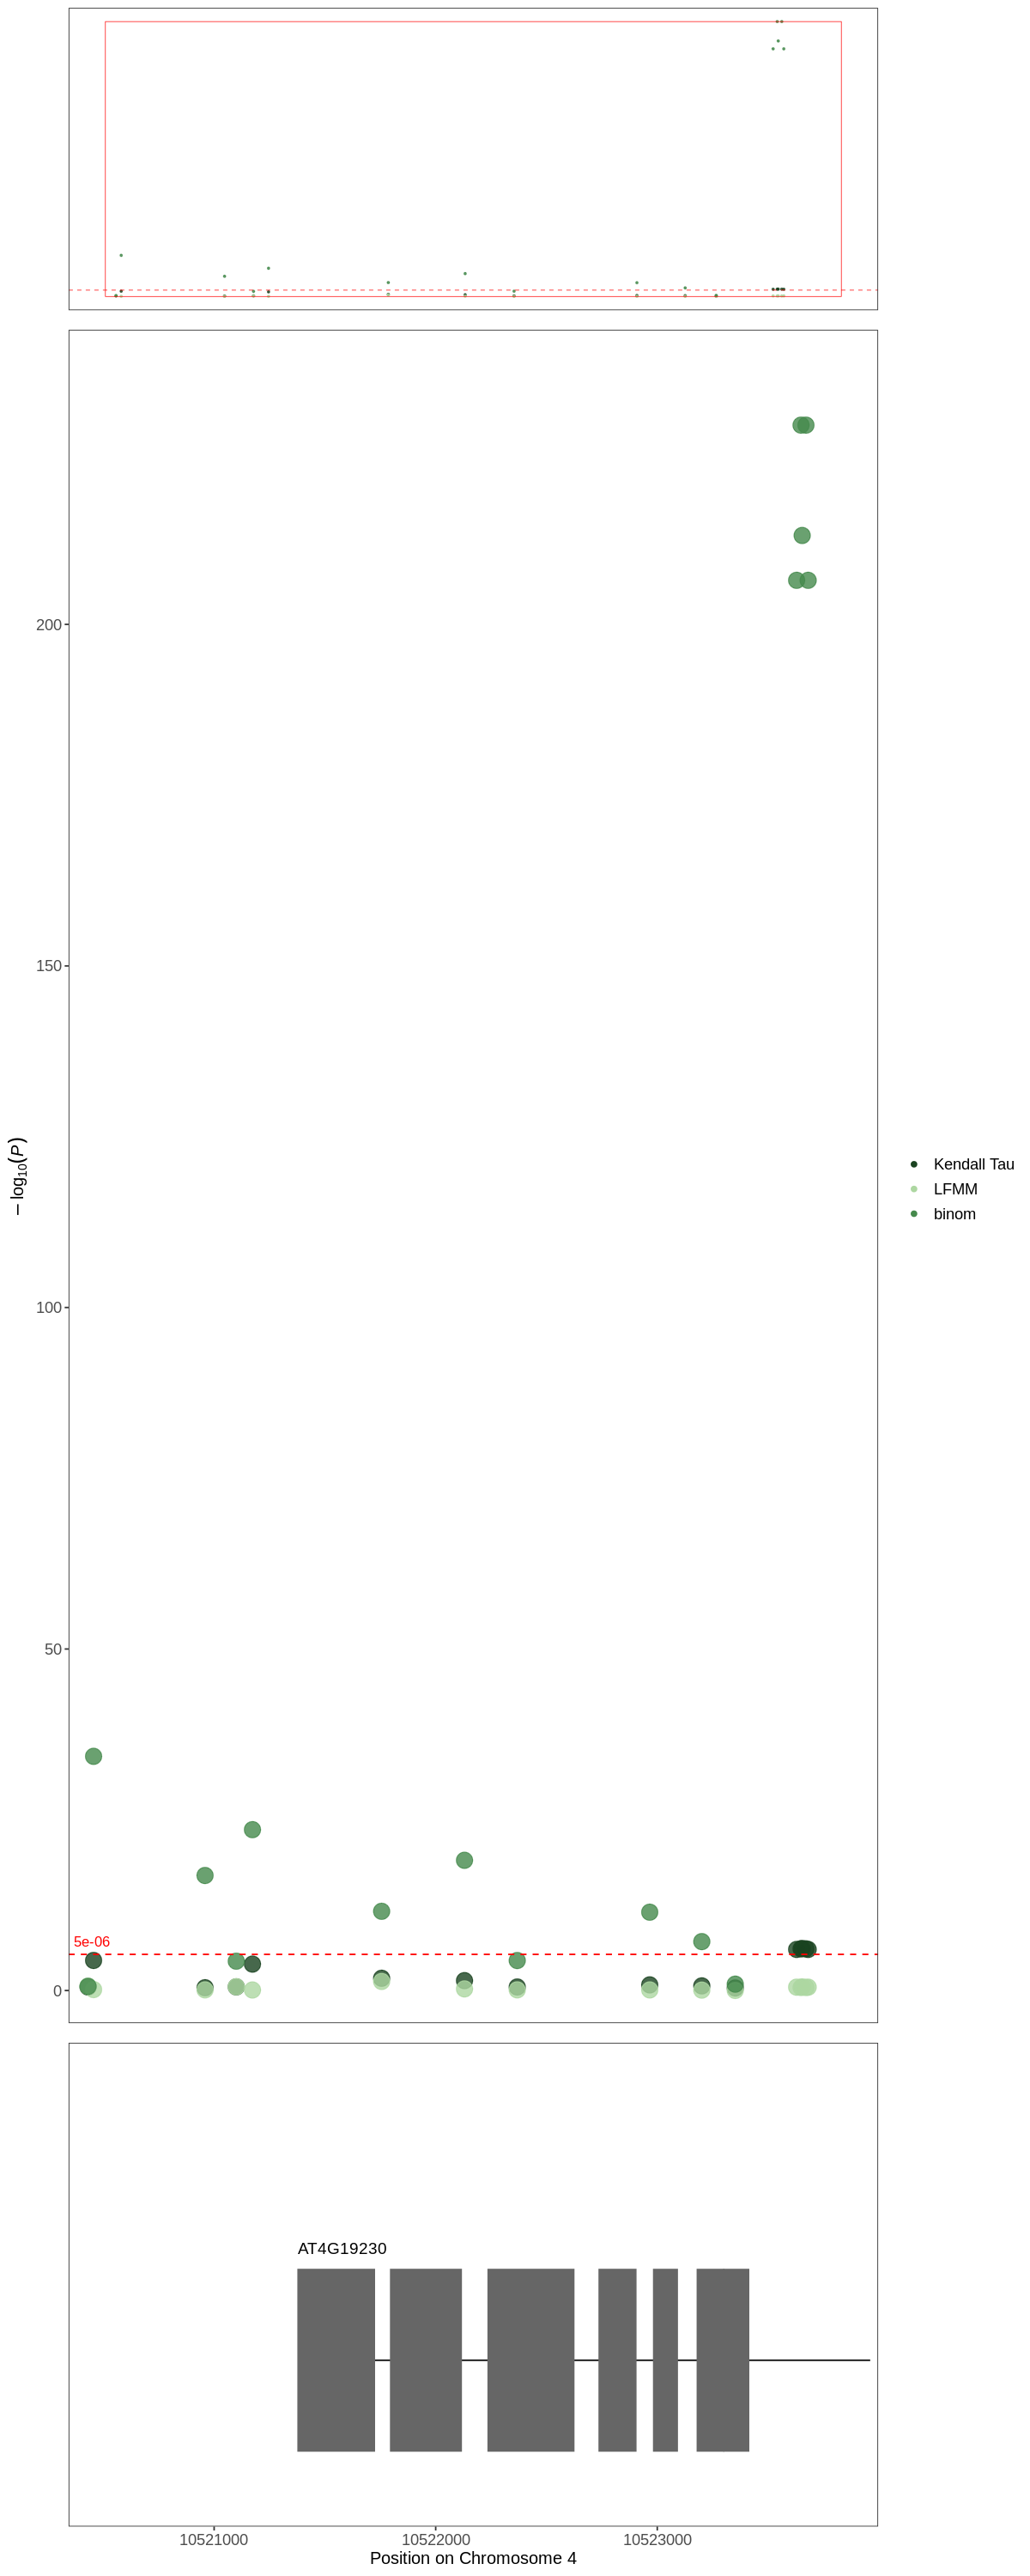

In [21]:
# Define hex colors manually
kendall_color <- "#1a4320"  # Green from Seaborn palette
lfmm_color <- "#ADD7A1"  # Purple from Seaborn palette
binom_color <- "#45894c"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 25)
regionplot(list(kendall, lfmm, binom), region="4:10520379-10523961", 
           build = arabidopsis, 
           sign_thresh=5e-06,
           color=c(kendall_color, lfmm_color, binom_color), 
           legend_labels = c("Kendall Tau", 'LFMM', 'binom'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)

# Add a vertical line manually in grey

In [22]:

pdf("regionplot_lfmm_kendall_cyt.pdf",width = 10, height = 25)

kendall_color <- "#1a4320"  # Green from Seaborn palette
lfmm_color <- "#ADD7A1"  # Purple from Seaborn palette
binom_color <- "#45894c"  # Orange from Seaborn palette
# Create the region plot

regionplot(list(kendall, lfmm, binom), region="4:10520379-10523961", 
           build = arabidopsis, 
           color=c(kendall_color, lfmm_color, binom_color), 
           legend_labels = c("Kendall Tau", 'LFMM', 'binom'), 
           gene_color="#666666", 
           alpha=0.8,
            sign_thresh=5e-06,
           size = 5)


# Add a vertical line manually in grey
dev.off()

[1] "Zoomed to region:  4:10520379-10523961"


png 
  2

In [46]:
#kendall[order(kendall$P), ]

In [47]:
#lfmm[order(lfmm$P), ]

In [48]:
#binom[order(binom$P), ]

In [ ]:
## lfmm

In [109]:
path_lfmm_es = '/carnegie/nobackup/scratch/tbellagio/gea_grene-net/lfmm_full_last_gen/effect_sizes_4_2320.csv'
lfmm_es <- read.csv(path_lfmm_es)

In [110]:
# Create a new 'id' column in the first data frame
lfmm$id <- paste(lfmm$CHROM, lfmm$POS, sep = "_")

# Merge the two data frames by 'id'
merged_df <- merge(lfmm, lfmm_es, by = "id")


In [114]:
merged_df <- merged_df[merged_df$P< 1e-3, ]

In [117]:
#merged_df[order(merged_df$POS), ]

In [112]:
# Create a DataFrame where bio1 > 0
df_bio1_positive <- merged_df[merged_df$bio1 > 0, ]

# Create a DataFrame where bio1 < 0
df_bio1_negative <- merged_df[merged_df$bio1 < 0, ]

In [ ]:
## kendall


In [125]:
path_lfmm_es = '/carnegie/nobackup/scratch/tbellagio/gea_grene-net/kendall_tau_last_gen/effect_sizes_4_2320.csv'
kendall_es <- read.csv(path_lfmm_es)

In [127]:
# Create a new 'id' column in the first data frame
kendall$id <- paste(kendall$CHROM, kendall$POS, sep = "_")

# Merge the two data frames by 'id'
merged_df <- merge(kendall, kendall_es, by = "id")

In [135]:
merged_df <- merged_df[merged_df$P< 1e-3, ]

In [136]:
# Create a DataFrame where bio1 > 0
df_bio1_positive <- merged_df[merged_df$K_tau > 0, ]

# Create a DataFrame where bio1 < 0
df_bio1_negative <- merged_df[merged_df$K_tau < 0, ]

In [158]:
## binom 
path_binom_es = '/carnegie/nobackup/scratch/tbellagio/gea_grene-net/binomial_regression_lastgen/effect_sizes_4_2320.csv'
binom_es <- read.csv(path_binom_es)

In [159]:
# Create a new 'id' column in the first data frame
binom$snp_id <- paste(binom$CHROM, binom$POS, sep = "_")

# Merge the two data frames by 'id'
merged_df <- merge(binom, binom_es, by = "snp_id")

In [160]:
merged_df <- merged_df[merged_df$P< 1e-3, ]

In [161]:
# Create a DataFrame where bio1 > 0
df_bio1_positive <- merged_df[merged_df$slope > 0, ]

# Create a DataFrame where bio1 < 0
df_bio1_negative <- merged_df[merged_df$slope < 0, ]

1 zero-value p-value (P<2.2e-308 (.Machine$double.xmin)) found in the input dastaset and excluded from the plot: 4:10999188
[1] "Zoomed to region:  4:10975621-11005174"


Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_rect()`).”


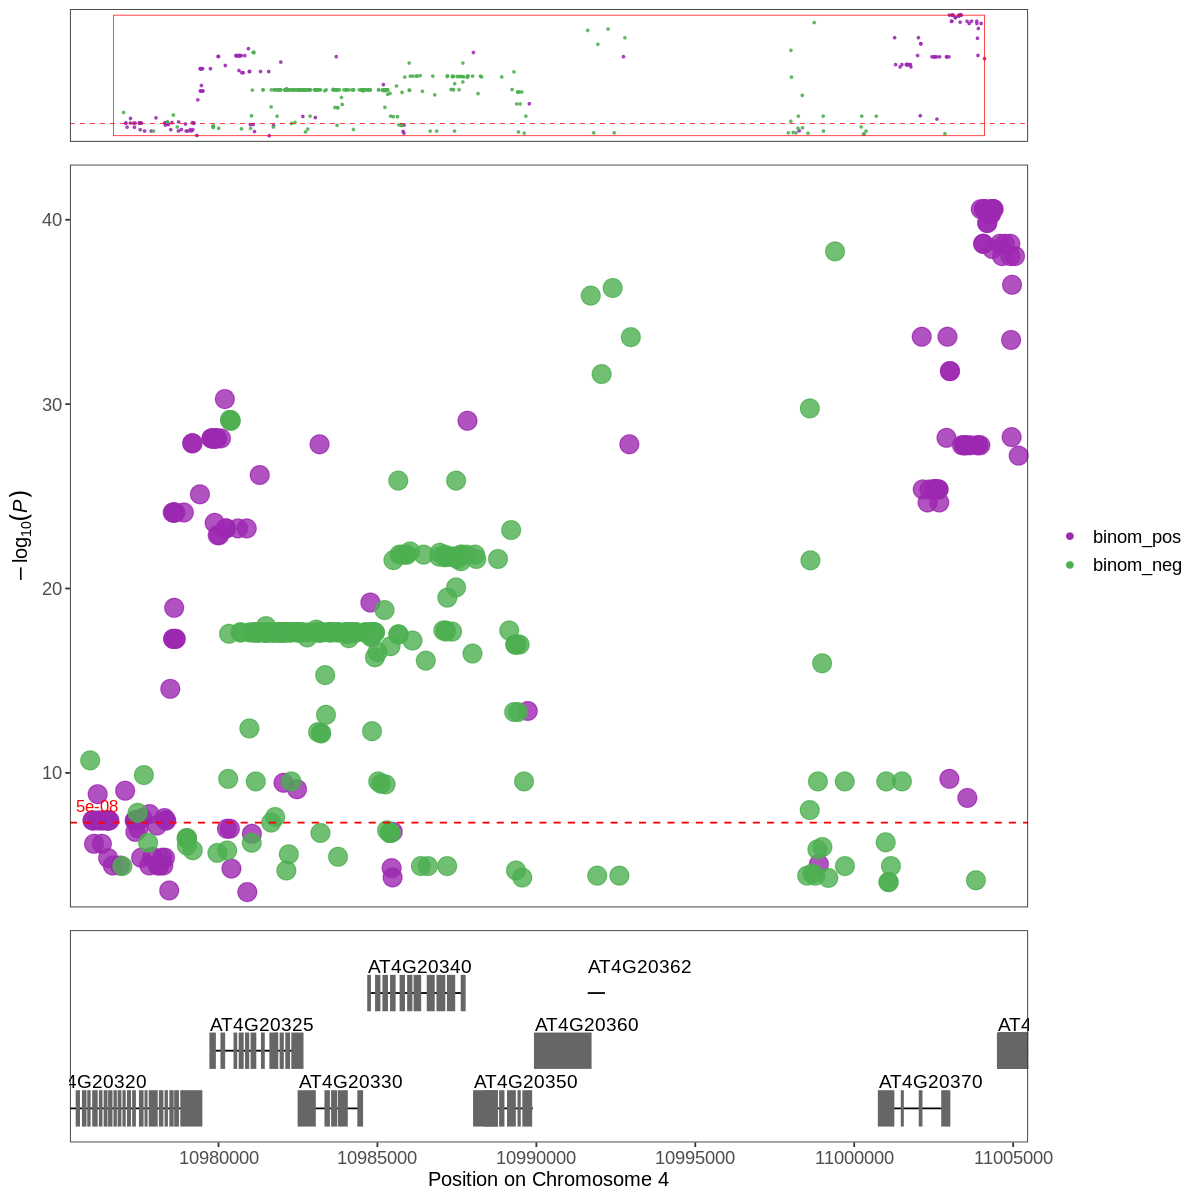

In [163]:
# Define hex colors manually

# tsf block 4:10975621-11005174
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(df_bio1_positive, df_bio1_negative), region="4:10975621-11005174",  # 10521379 - 10523961
           build = arabidopsis, 
           color=c(purple_hex, green_hex), 
           legend_labels = c('binom_pos', 'binom_neg'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)

[1] "Zoomed to region:  4:10975621-11005174"


Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_rect()`).”


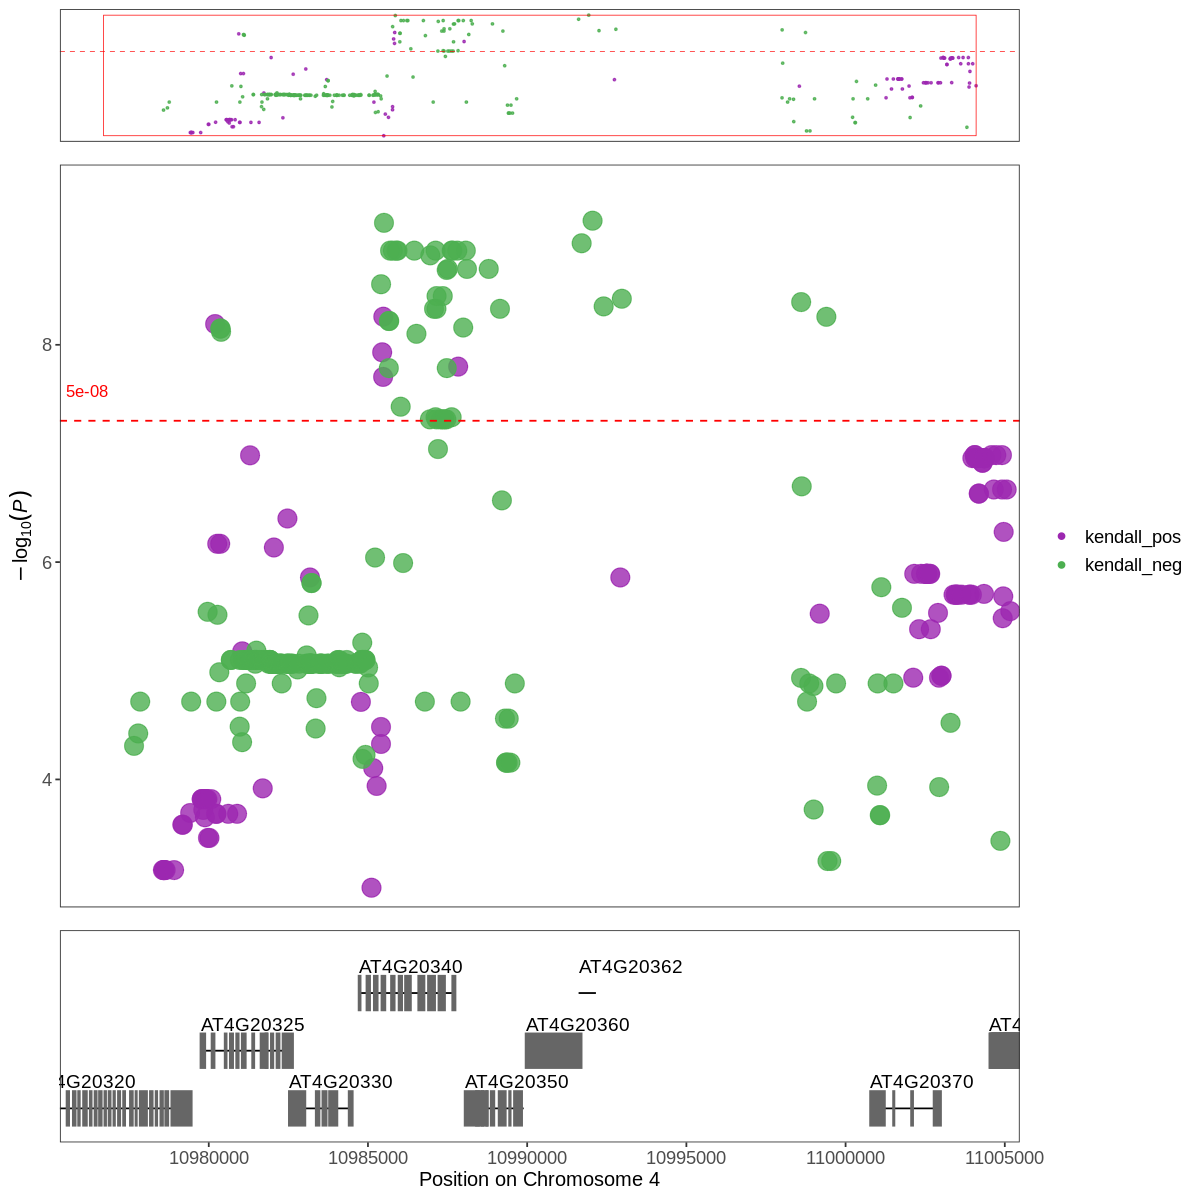

In [137]:
# Define hex colors manually

# tsf block 4:10975621-11005174
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(df_bio1_positive, df_bio1_negative), region="4:10975621-11005174",  # 10521379 - 10523961
           build = arabidopsis, 
           color=c(purple_hex, green_hex), 
           legend_labels = c('kendall_pos', 'kendall_neg'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)

In [ ]:
path_lfmm_es = '/carnegie/nobackup/scratch/tbellagio/gea_grene-net/kendall_tau_last_gen/effect_sizes_4_2320.csv'
kendall_es <- read.csv(path_lfmm_es)

[1] "Zoomed to region:  4:10975621-11005174"


Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_rect()`).”


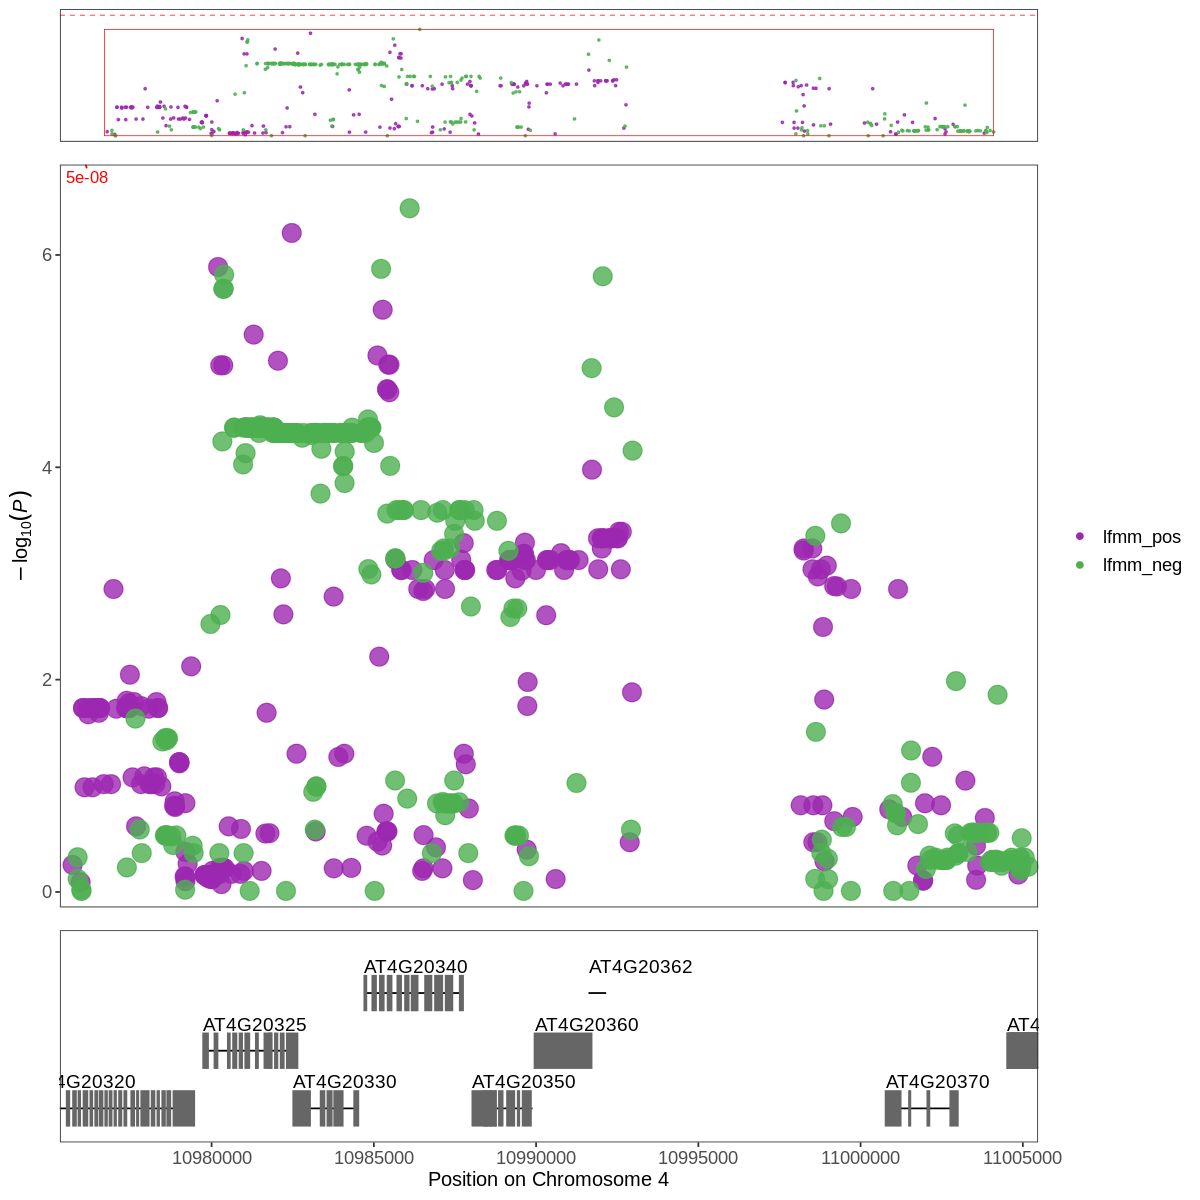

In [113]:
# Define hex colors manually

# tsf block 4:10975621-11005174
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(df_bio1_positive, df_bio1_negative), region="4:10975621-11005174",  # 10521379 - 10523961
           build = arabidopsis, 
           color=c(purple_hex, green_hex), 
           legend_labels = c('lfmm_pos', 'lfmm_neg'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)

[1] "Zoomed to region:  4:10975621-11005174"


Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_rect()`).”


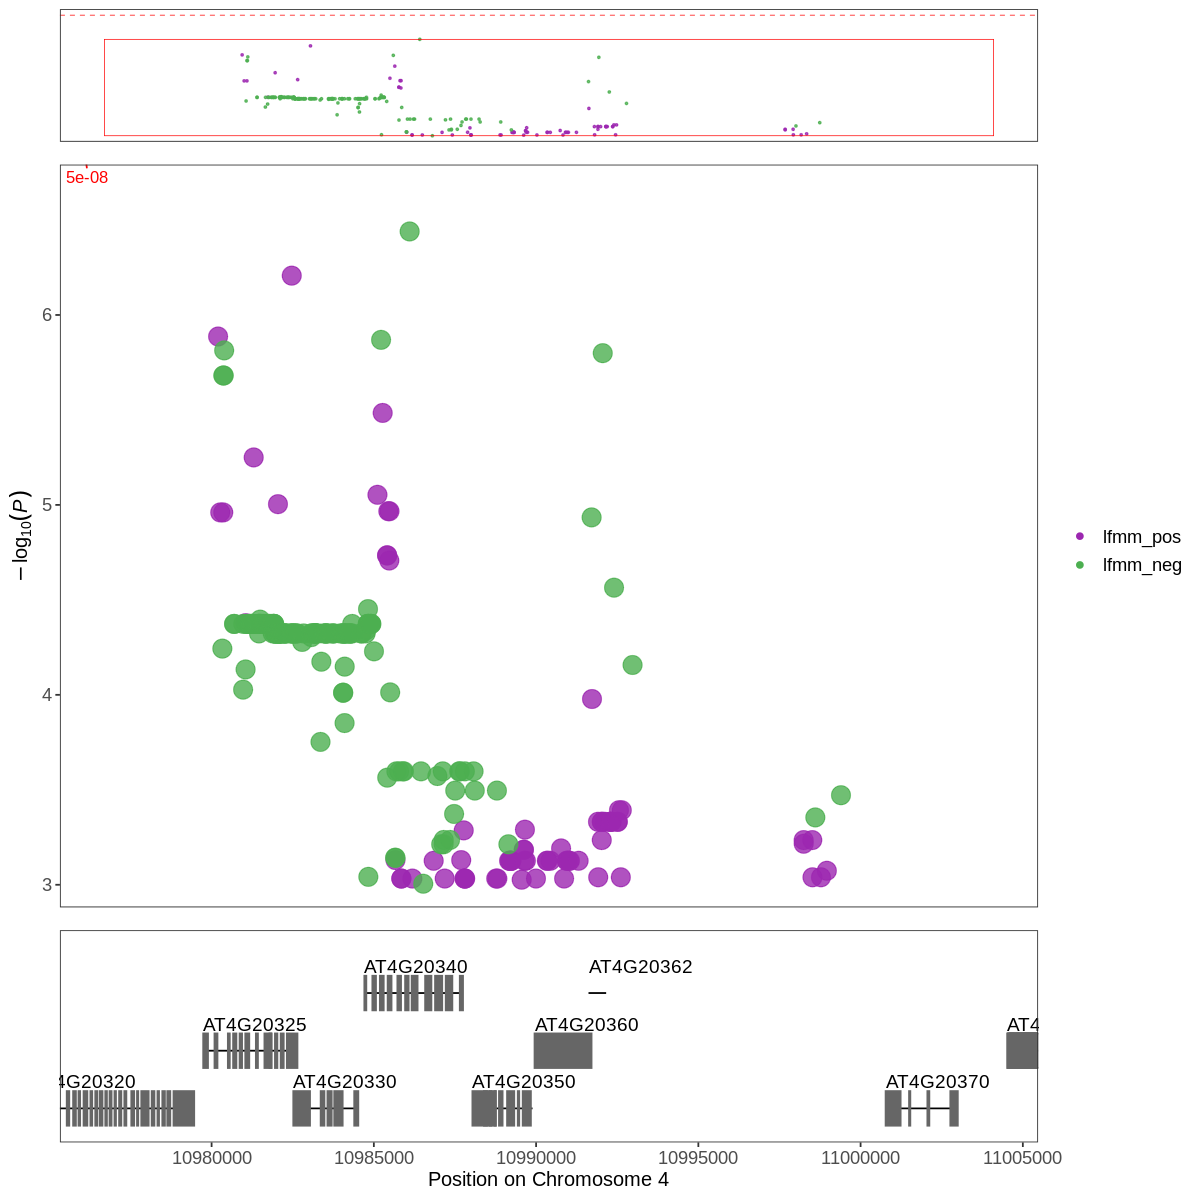

In [50]:
# Define hex colors manually

# tsf block 4:10975621-11005174
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(df_bio1_positive, df_bio1_negative), region="4:10975621-11005174",  # 10521379 - 10523961
           build = arabidopsis, 
           color=c(purple_hex, green_hex), 
           legend_labels = c('lfmm_pos', 'lfmm_neg'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)

[1] "Zoomed to region:  4:10975621-11010000"


Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_rect()`).”


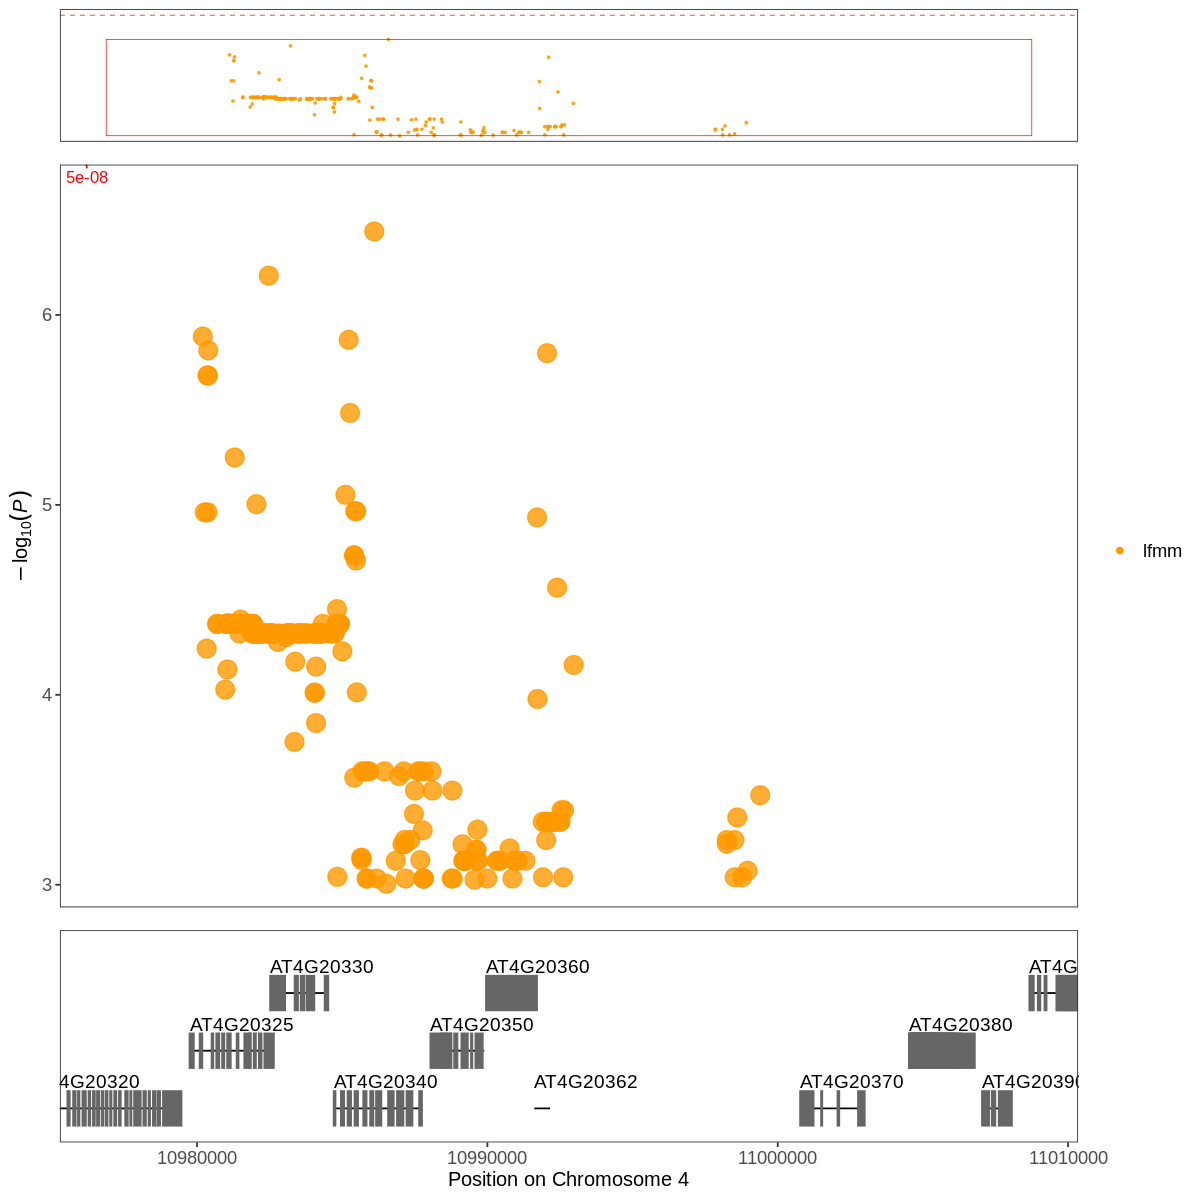

In [12]:
# Define hex colors manually

# tsf block 4:10975621-11005174
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(lfmm), region="4:10975621-11010000",  # 10521379 - 10523961
           build = arabidopsis, 
           color=c(orange_hex), 
           legend_labels = c('lfmm'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)

In [ ]:
# Define hex colors manually

# tsf block 4:10975621-11005174
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(lfmm), region="4:10975621-11010000",  # 10521379 - 10523961
           build = arabidopsis, 
           color=c(orange_hex), 
           legend_labels = c('lfmm'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)

[1] "Zoomed to region:  4:10975621-11005174"


Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_rect()`).”


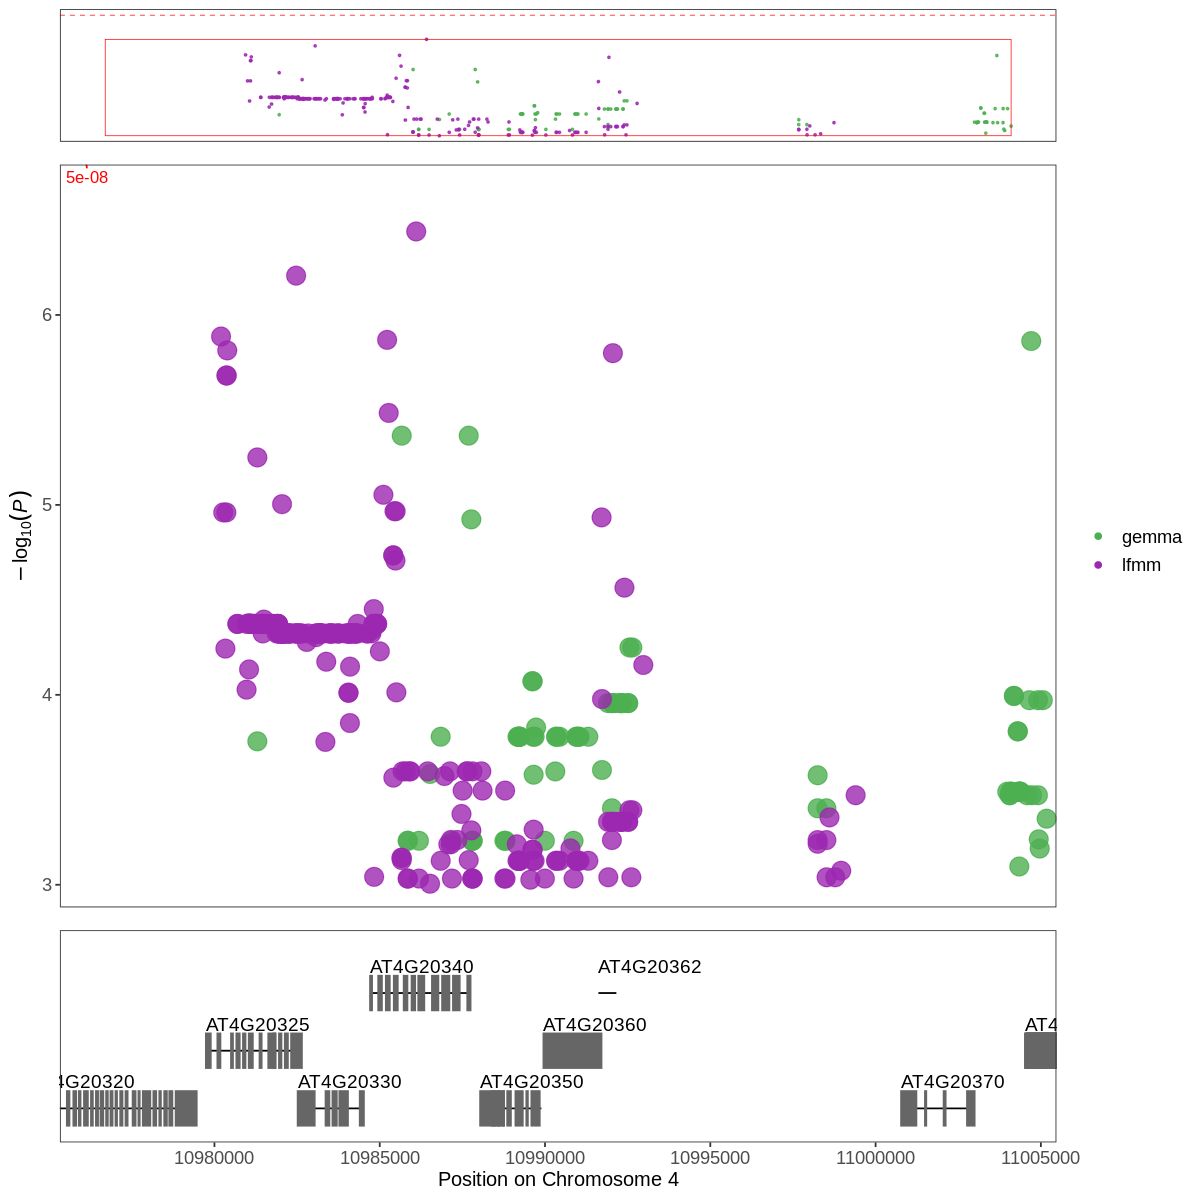

In [49]:
# Define hex colors manually

# tsf block 4:10975621-11005174
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(gemma, lfmm), region="4:10975621-11005174",  # 10521379 - 10523961
           build = arabidopsis, 
           color=c(green_hex, purple_hex), 
           legend_labels = c("gemma", 'lfmm'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)


[1] "Zoomed to region:  4:10995000-11005174"


Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_rect()`).”


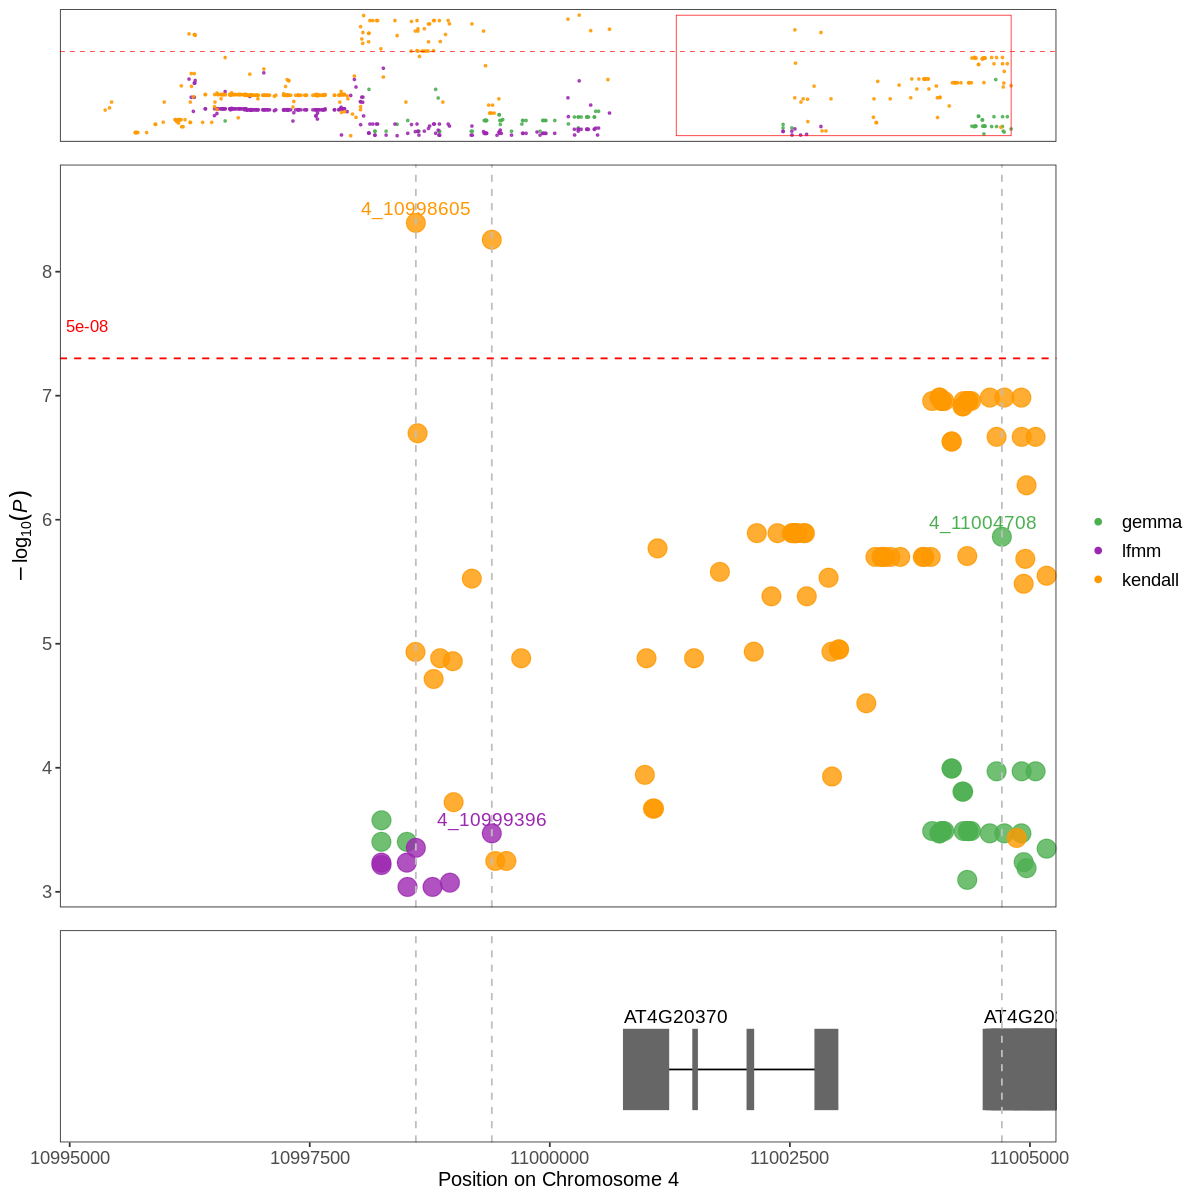

In [74]:
# Define hex colors manually

# tsf block 4:10975621-11005174
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette
red_hex = '#ff0000'
# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(gemma, lfmm, kendall), region="4:10995000-11005174",  # 10521379 - 10523961
           build = arabidopsis, 
           color=c(green_hex, purple_hex, orange_hex, red_hex), 
           legend_labels = c("gemma", 'lfmm', 'kendall'), 
            annotate_with_vline=1e-3,
           gene_color="#666666", 
           alpha=0.8,
           size = 5)


In [71]:
pdf("regionplot_TSF_gemma_n_lfmm.pdf")

# Create the region plot
regionplot(list(gemma, lfmm), region="4:10995000-11005174",  # 10521379 - 10523961
           build = arabidopsis, 
           color=c(green_hex, purple_hex), 
           legend_labels = c("gemma", 'lfmm'), 
            annotate_with_vline=1e-3,
           gene_color="#666666", 
           alpha=0.8,
           size = 5)


# Add a vertical line manually in grey
dev.off()

[1] "Zoomed to region:  4:10995000-11005174"


Warning message:
“Removed 9 rows containing missing values or values outside the scale range
(`geom_rect()`).”


png 
  2

[1] "Zoomed to region:  4:11000771-11003010"


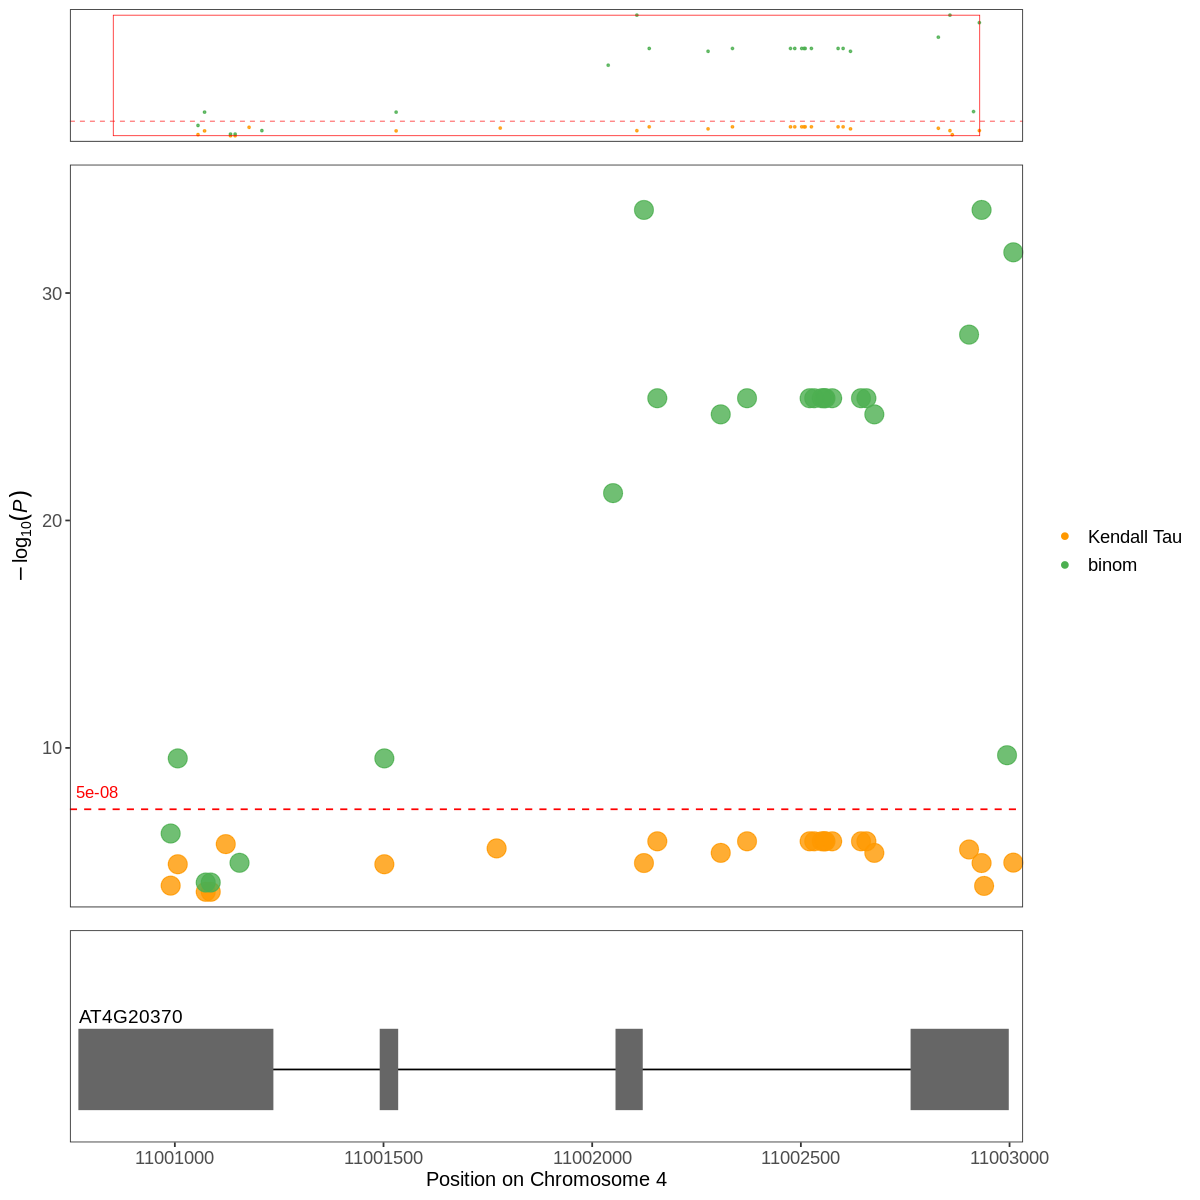

In [24]:
# Define hex colors manually
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(kendall, binom), region="4:11000771-11003010",  # 10521379 - 10523961
           build = arabidopsis, 
           color=c(orange_hex, green_hex, purple_hex), 
           legend_labels = c("Kendall Tau", 'binom'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)

# Add a vertical line manually in grey

In [40]:
# Define hex colors manually
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(kendall, lfmm, binom), region="4:10523625-10524180", 
           build = arabidopsis, 
           color=c(orange_hex, green_hex, purple_hex), 
           legend_labels = c("Kendall Tau", 'LFMM', 'binom'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)

# Add a vertical line manually in grey

Warning message in dat_check(df, verbose = verbose, locuszoomplot = locuszoomplot):
“Dataset [2] is empty with 0 rows. Please remove it from the input list and re-run!”


ERROR: Error in `$<-.data.frame`(`*tmp*`, "size", value = 0.4): replacement has 1 row, data has 0


In [ ]:
tsf Chr4:11000771..11003010

In [ ]:
 lsd1 11004517 - 11006788   4:10975621-11005174

[1] "Zoomed to region:  4:10521379-10523961"


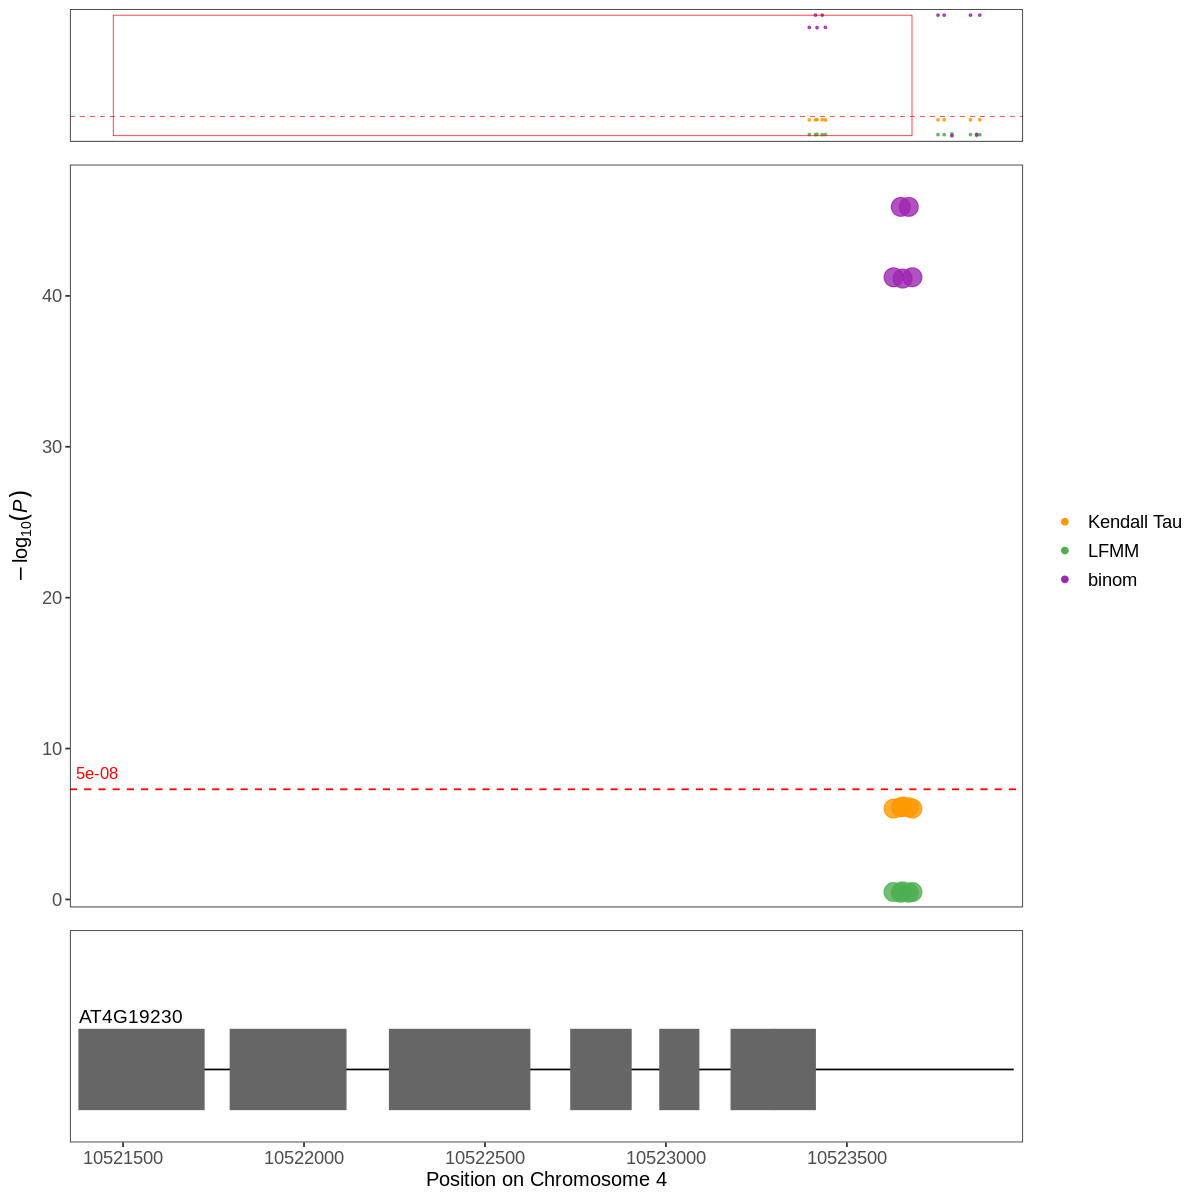

In [10]:
# Define hex colors manually
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(kendall, lfmm, binom), region="4:10521379-10523961", 
           build = arabidopsis, 
           color=c(orange_hex, green_hex, purple_hex), 
           legend_labels = c("Kendall Tau", 'LFMM', 'binom'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)

# Add a vertical line manually in grey

[1] "Zoomed to region:  2:11531800-11534400"


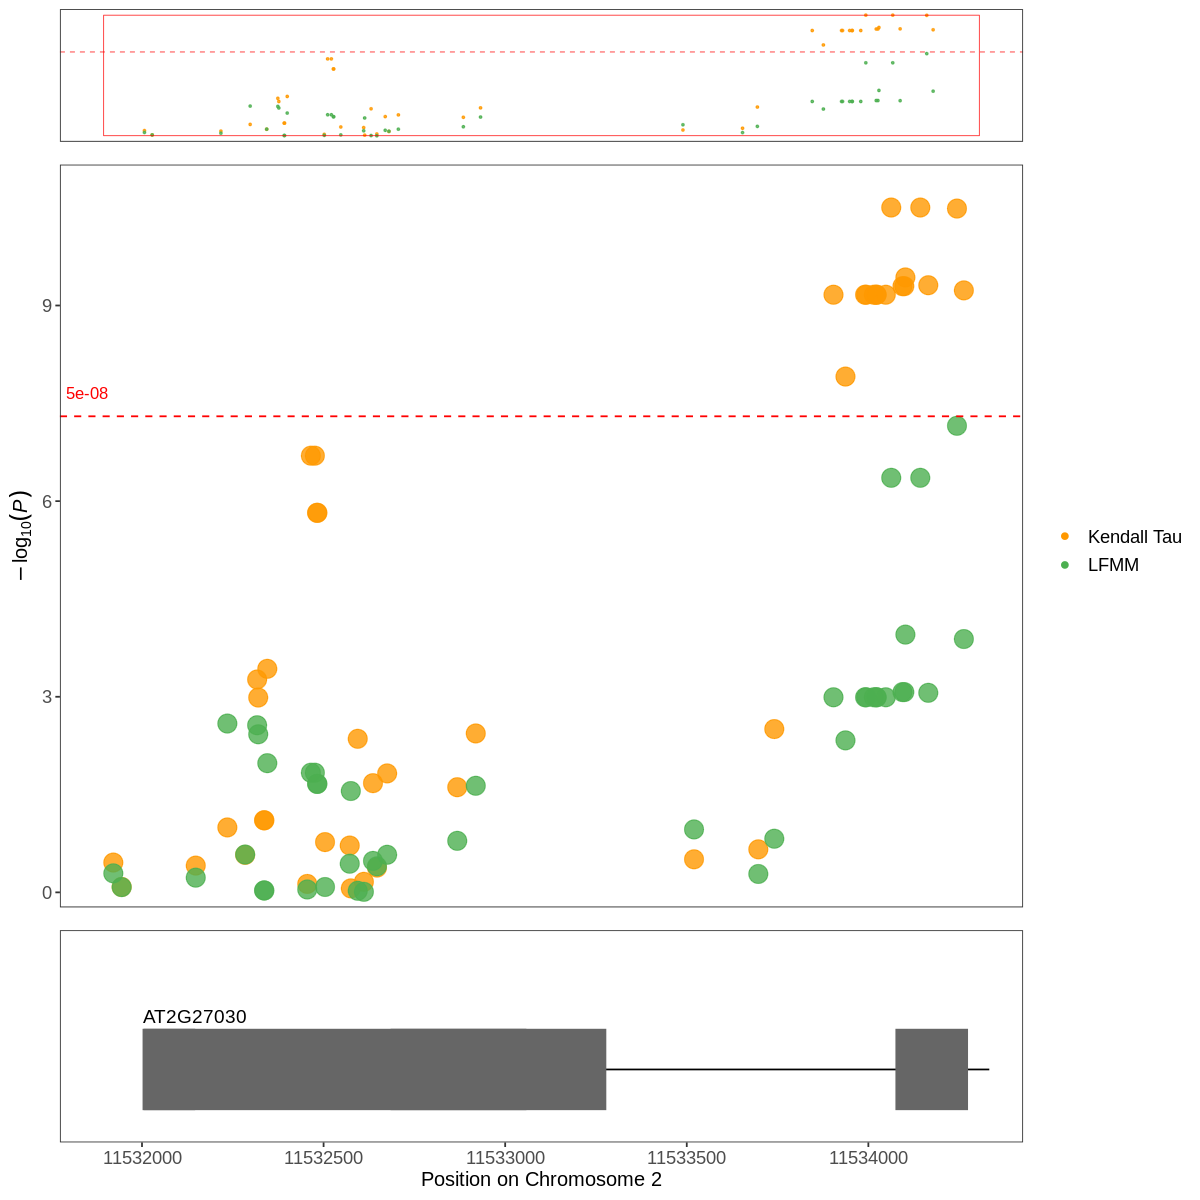

In [48]:
# Define hex colors manually
green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot
options(repr.plot.width = 10, repr.plot.height = 10)
regionplot(list(kendall, lfmm), region="2:11531800-11534400", 
           build = arabidopsis, 
           color=c(orange_hex, green_hex, purple_hex), 
           legend_labels = c("Kendall Tau", 'LFMM'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)

# Add a vertical line manually in grey

In [ ]:
#options(repr.plot.width = 25, repr.plot.height = 12)
pdf("regionplot_lfmm_kendall_cyt.pdf")

green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot


regionplot(list(kendall, lfmm, binom), region="4:10521379-10523961", 
           build = arabidopsis, 
           color=c(orange_hex, green_hex, purple_hex), 
           legend_labels = c("Kendall Tau", 'LFMM', 'binom'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)


# Add a vertical line manually in grey
dev.off()

In [51]:
pdf("regionplot_lfmm_kendall_block_2_1265.pdf")

green_hex <- "#4CAF50"  # Green from Seaborn palette
purple_hex <- "#9C27B0"  # Purple from Seaborn palette
orange_hex <- "#FF9800"  # Orange from Seaborn palette

# Create the region plot

regionplot(list(kendall, lfmm, binom), region="2:11531800-11534400", 
           build = arabidopsis, 
           color=c(orange_hex, green_hex, purple_hex), 
           legend_labels = c("Kendall Tau", 'LFMM', 'binom'), 
           gene_color="#666666", 
           alpha=0.8,
           size = 5)


# Add a vertical line manually in grey
dev.off()

[1] "Zoomed to region:  2:11531800-11534400"


png 
  2

In [ ]:
 11,533,904 to 11,534,263

In [ ]:
block 2_1265 2:11533904-11534263
gene cam5 is 2:11531967-11534358

[1] "Zoomed to region:  2:11533904-11534263"


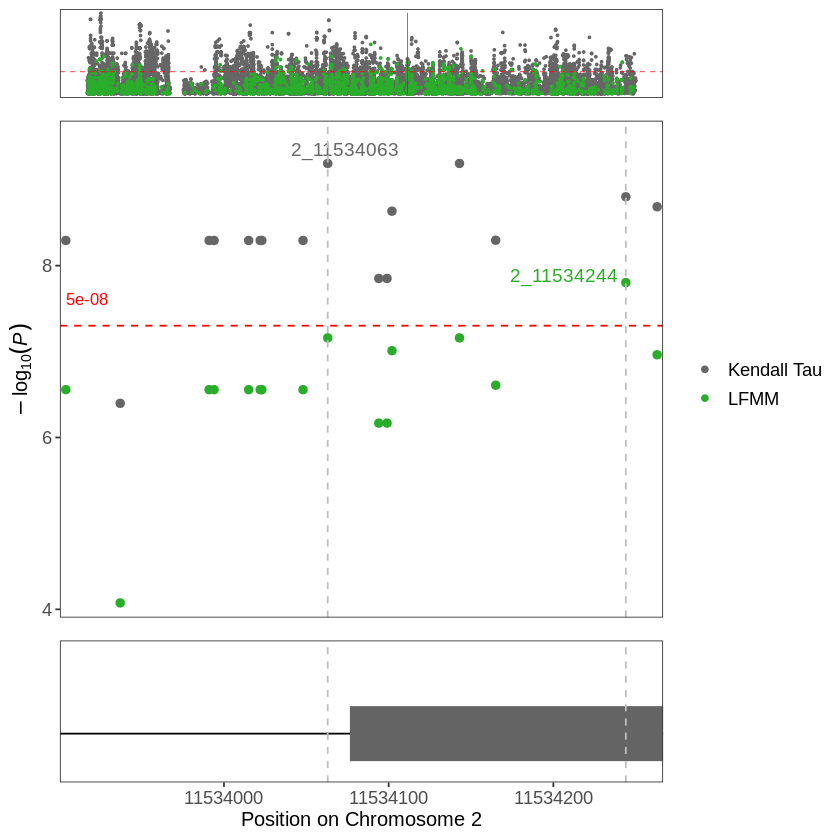

In [10]:
### exploring hte higest peak of LFMM
regionplot(list(kendall, lfmm), region="2:11533904-11534263", 
           build = arabidopsis, 
           color=c("#666666","#2aad2a"),
           legend_labels = c("Kendall Tau", 'LFMM'), vline=1e-8, 
           annotate_with_vline=1e-6,
           gene_color="#646464")

[1] "Zoomed to region:  2:11531967-11534358"


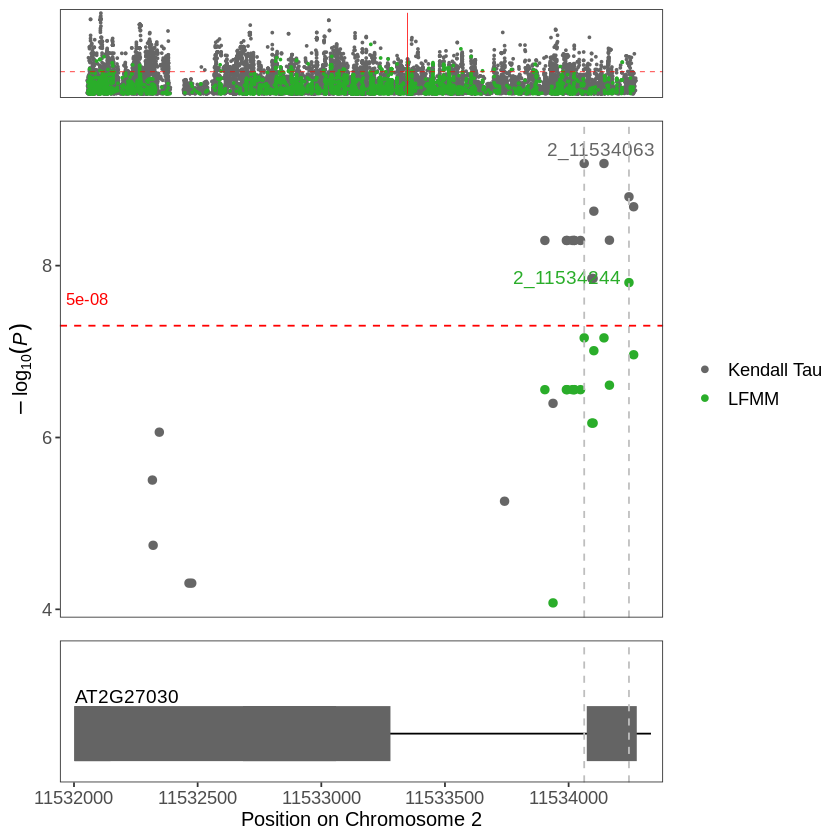

In [8]:
### exploring hte higest peak of LFMM
regionplot(list(kendall, lfmm), region="2:11531967-11534358", 
           build = arabidopsis, 
           color=c("#666666","#2aad2a"),
           legend_labels = c("Kendall Tau", 'LFMM'), vline=1e-8, 
           annotate_with_vline=1e-6,
           gene_color="#646464")

In [29]:
AT4G12120

ERROR: Error in eval(expr, envir, enclos): object 'AT4G12120' not found


In [ ]:
1_485
1_3995653
1_3997916
1_702
1_6018870
1_6181134
1_2867
1_20800345
1_20814896


2_827
2_7553538
2_7567816
2_970
2_9540996
2_9714921
2_1265
2_11533904
2_11534263


3_137
3_1540490
3_1548153

3_250
3_2346807
3_2350128


4_801
4_7255726
4_7269426


5_1947

5_17738817
5_17759685
5_2922
5_24100585
5_24286474

In [ ]:
3:1540490-1548153

3:2346807-2350128


In [ ]:
10,911,132 - 10,913,190 

In [ ]:
5_24100585
5_24286474

In [ ]:
"3:2346807-2350128", 

[1] "Zoomed to region:  2:2359861-2624928"


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_rect()`).”


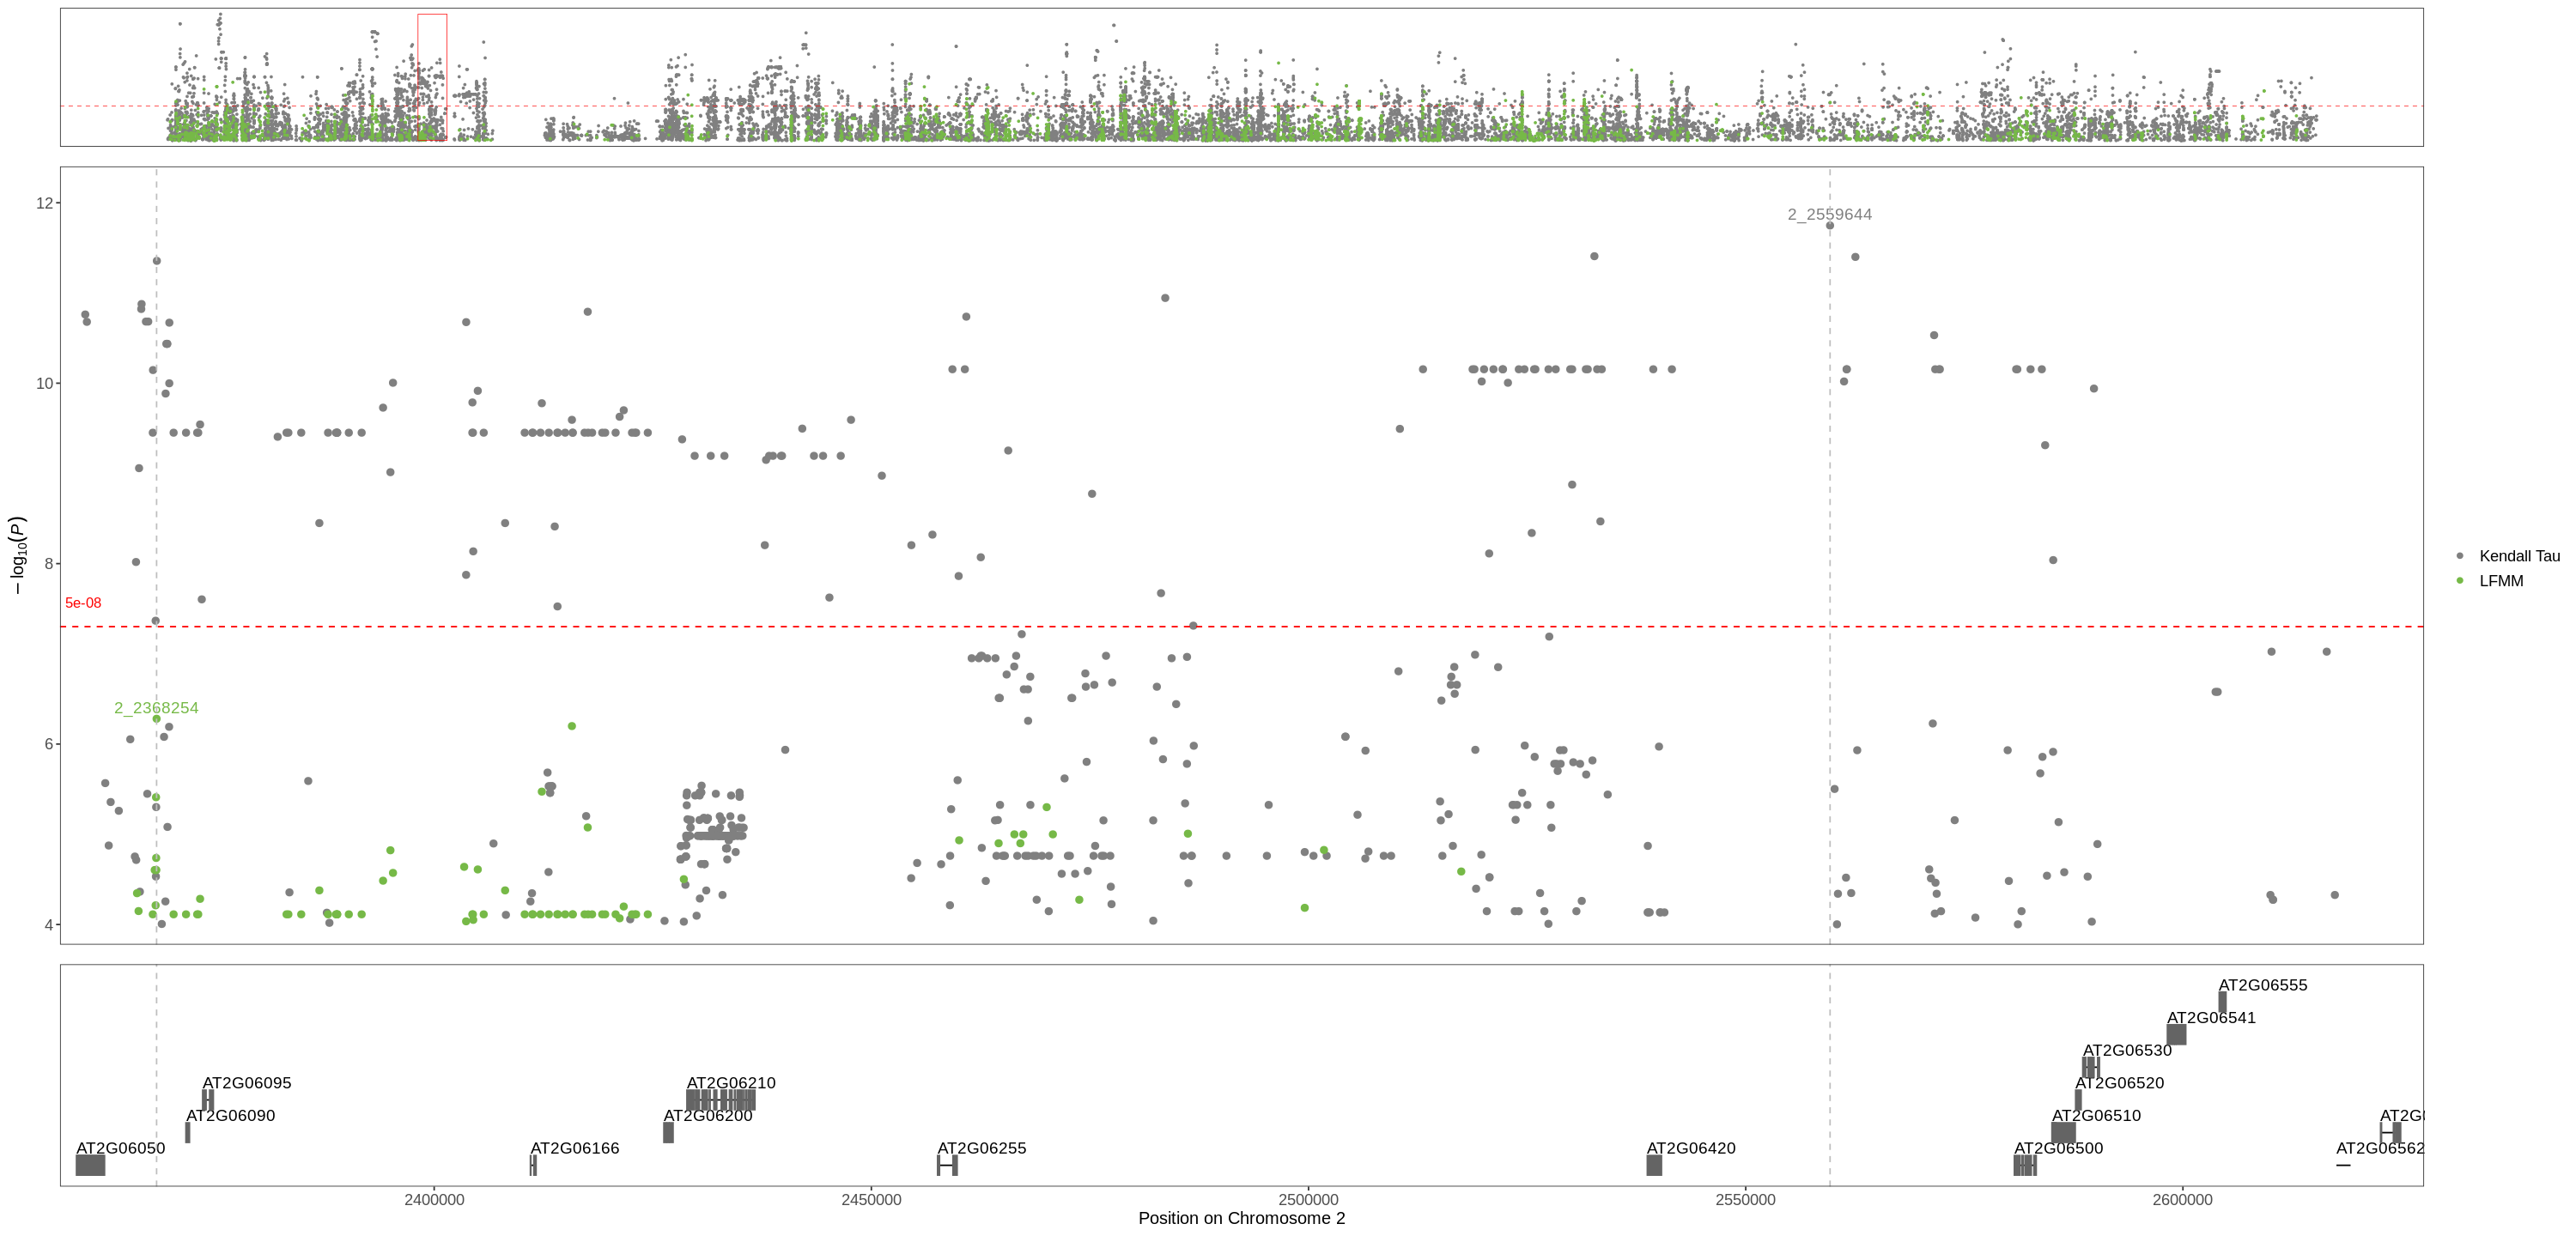

In [8]:
options(repr.plot.width = 25, repr.plot.height = 12)
### exploring hte higest peak of LFMM
regionplot(list(kendall, lfmm), region="2:2359861-2624928", 
           build = arabidopsis, 
           color=c("#808080","#76B947"),
           legend_labels = c("Kendall Tau", 'LFMM'), vline=1e-8, 
           annotate_with_vline=1e-6,
           gene_color="#646464")

In [ ]:
24150000

In [ ]:
'AT2G27030'

In [ ]:
regionplot(CD_UKBB, gene="Cps1", build=mm39)

In [ ]:
manhattan(CD_UKBB, annotate=5e-09)

In [ ]:
['11532004,11532687,11532007,11532004,11532687,11534077'] 
['11532144,11533276,11534272,11532144,11533056,11534333'],

[1] "Zoomed to region:  2:11531000-11535000"


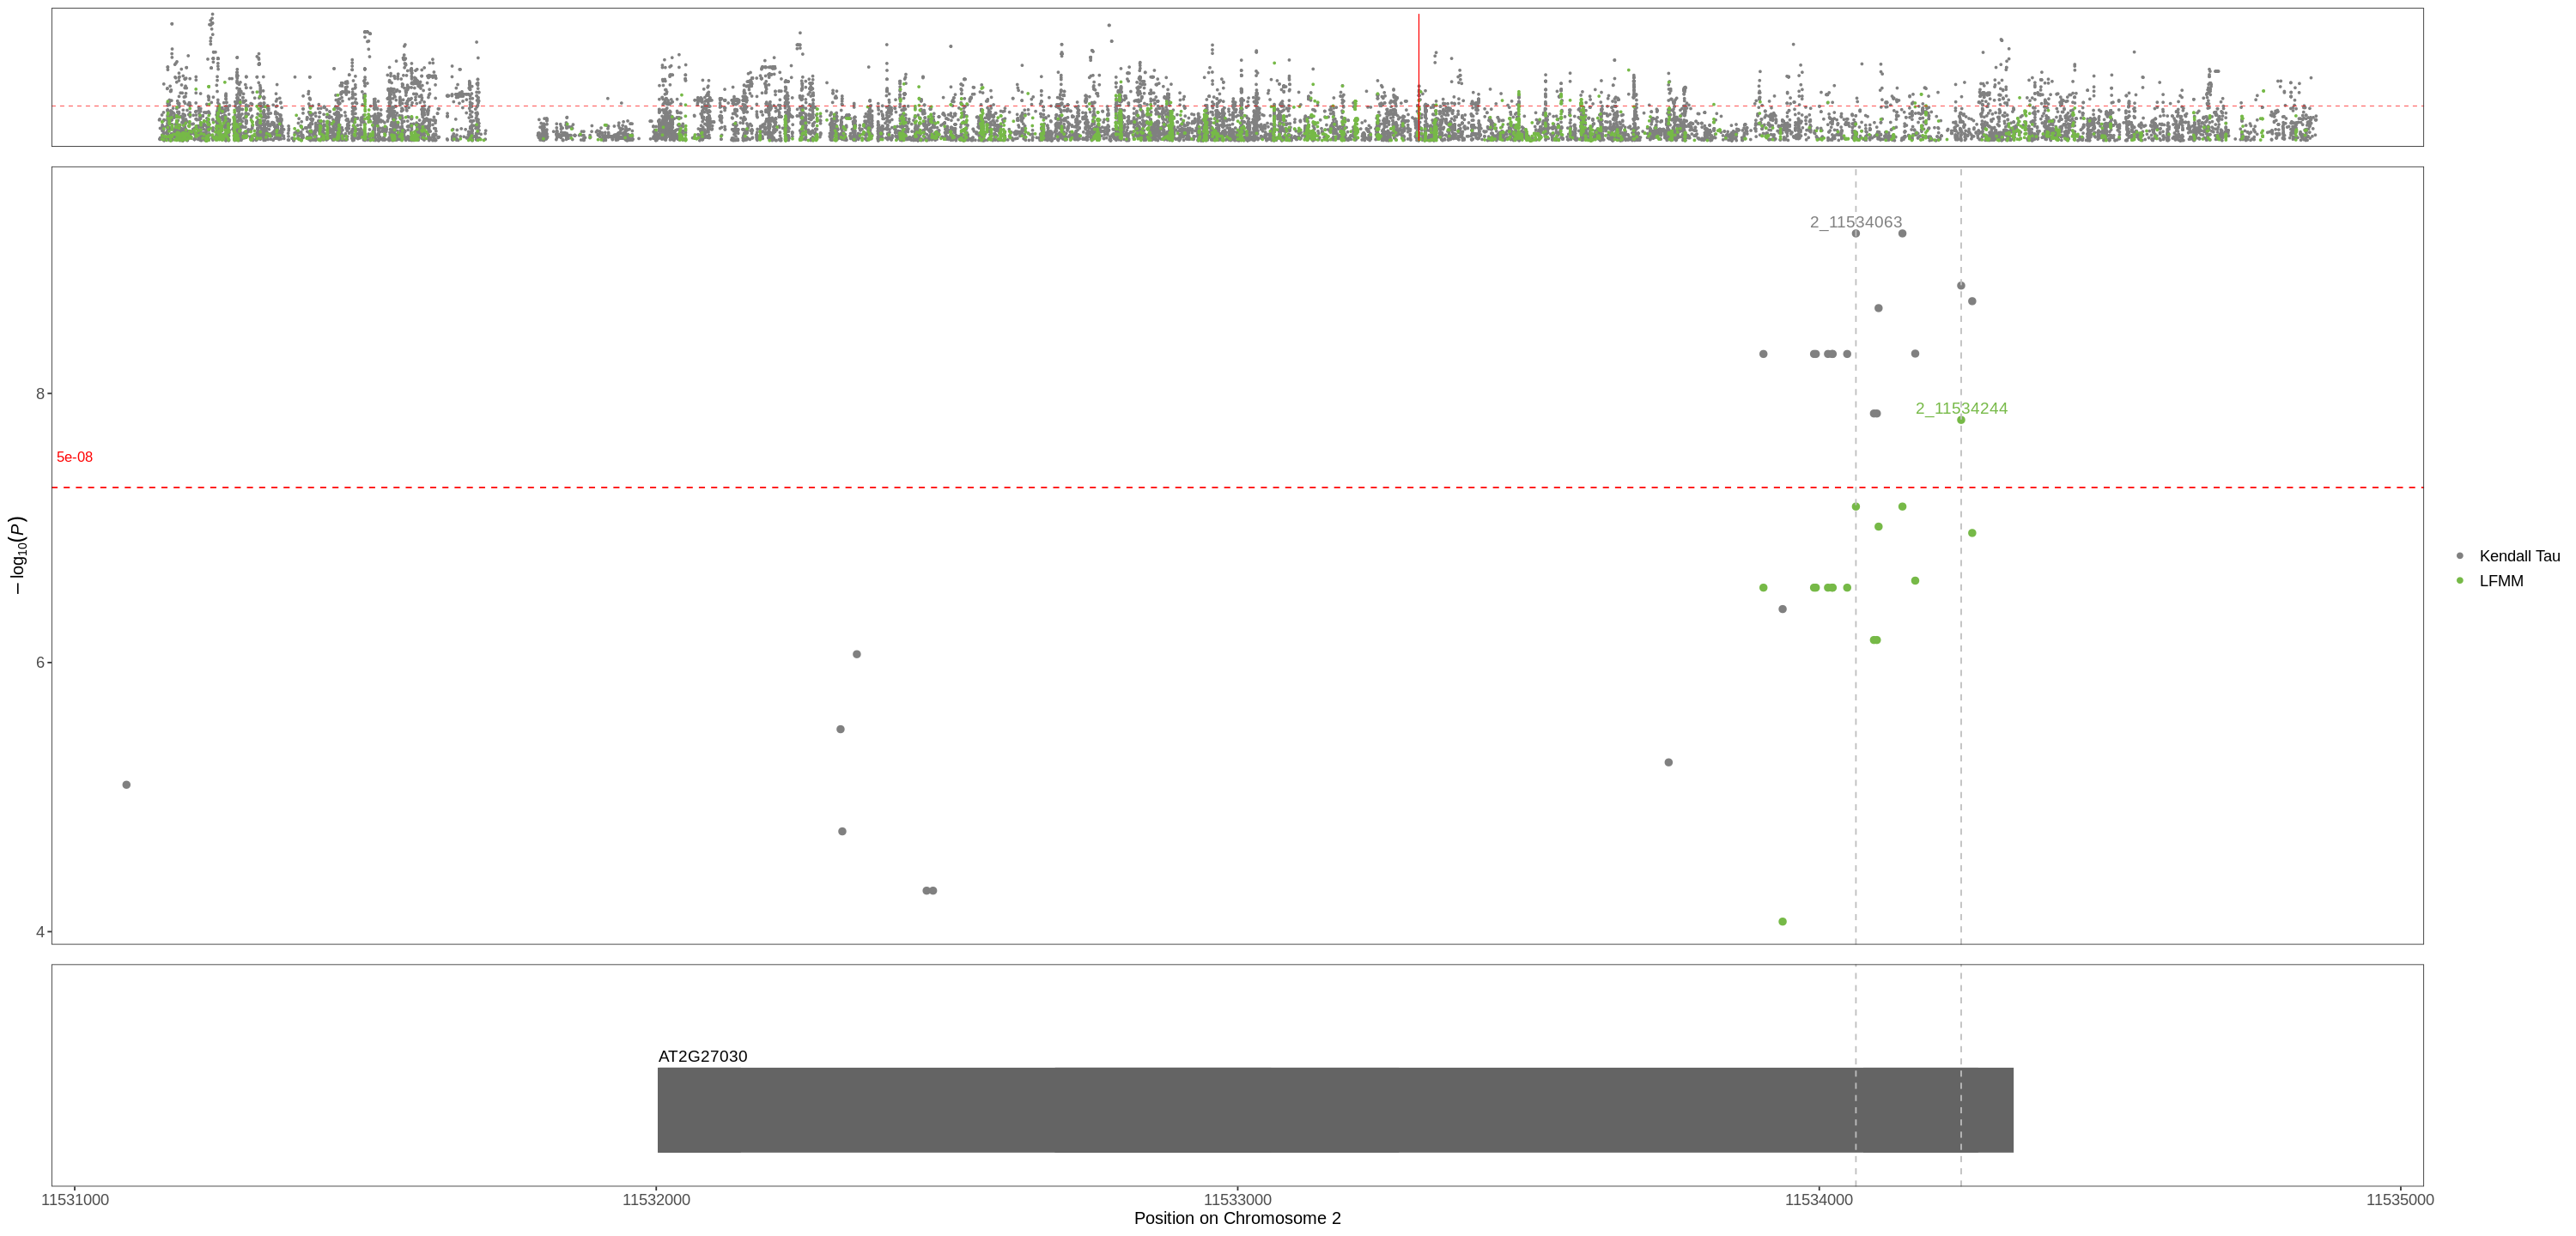

In [56]:
options(repr.plot.width = 25, repr.plot.height = 12)
### exploring hte higest peak of LFMM
regionplot(list(kendall, lfmm), build = annotations, color=c("#808080","#76B947"),
           legend_labels = c("Kendall Tau", 'LFMM'), annotate_with_vline=1e-6,region="2:11531000-11535000", show_gene_names = TRUE, 
           gene_color="#646464")

In [ ]:
region="2:11531000-11535000"

[1] "Zoomed to region:  2:11530000-11535000"


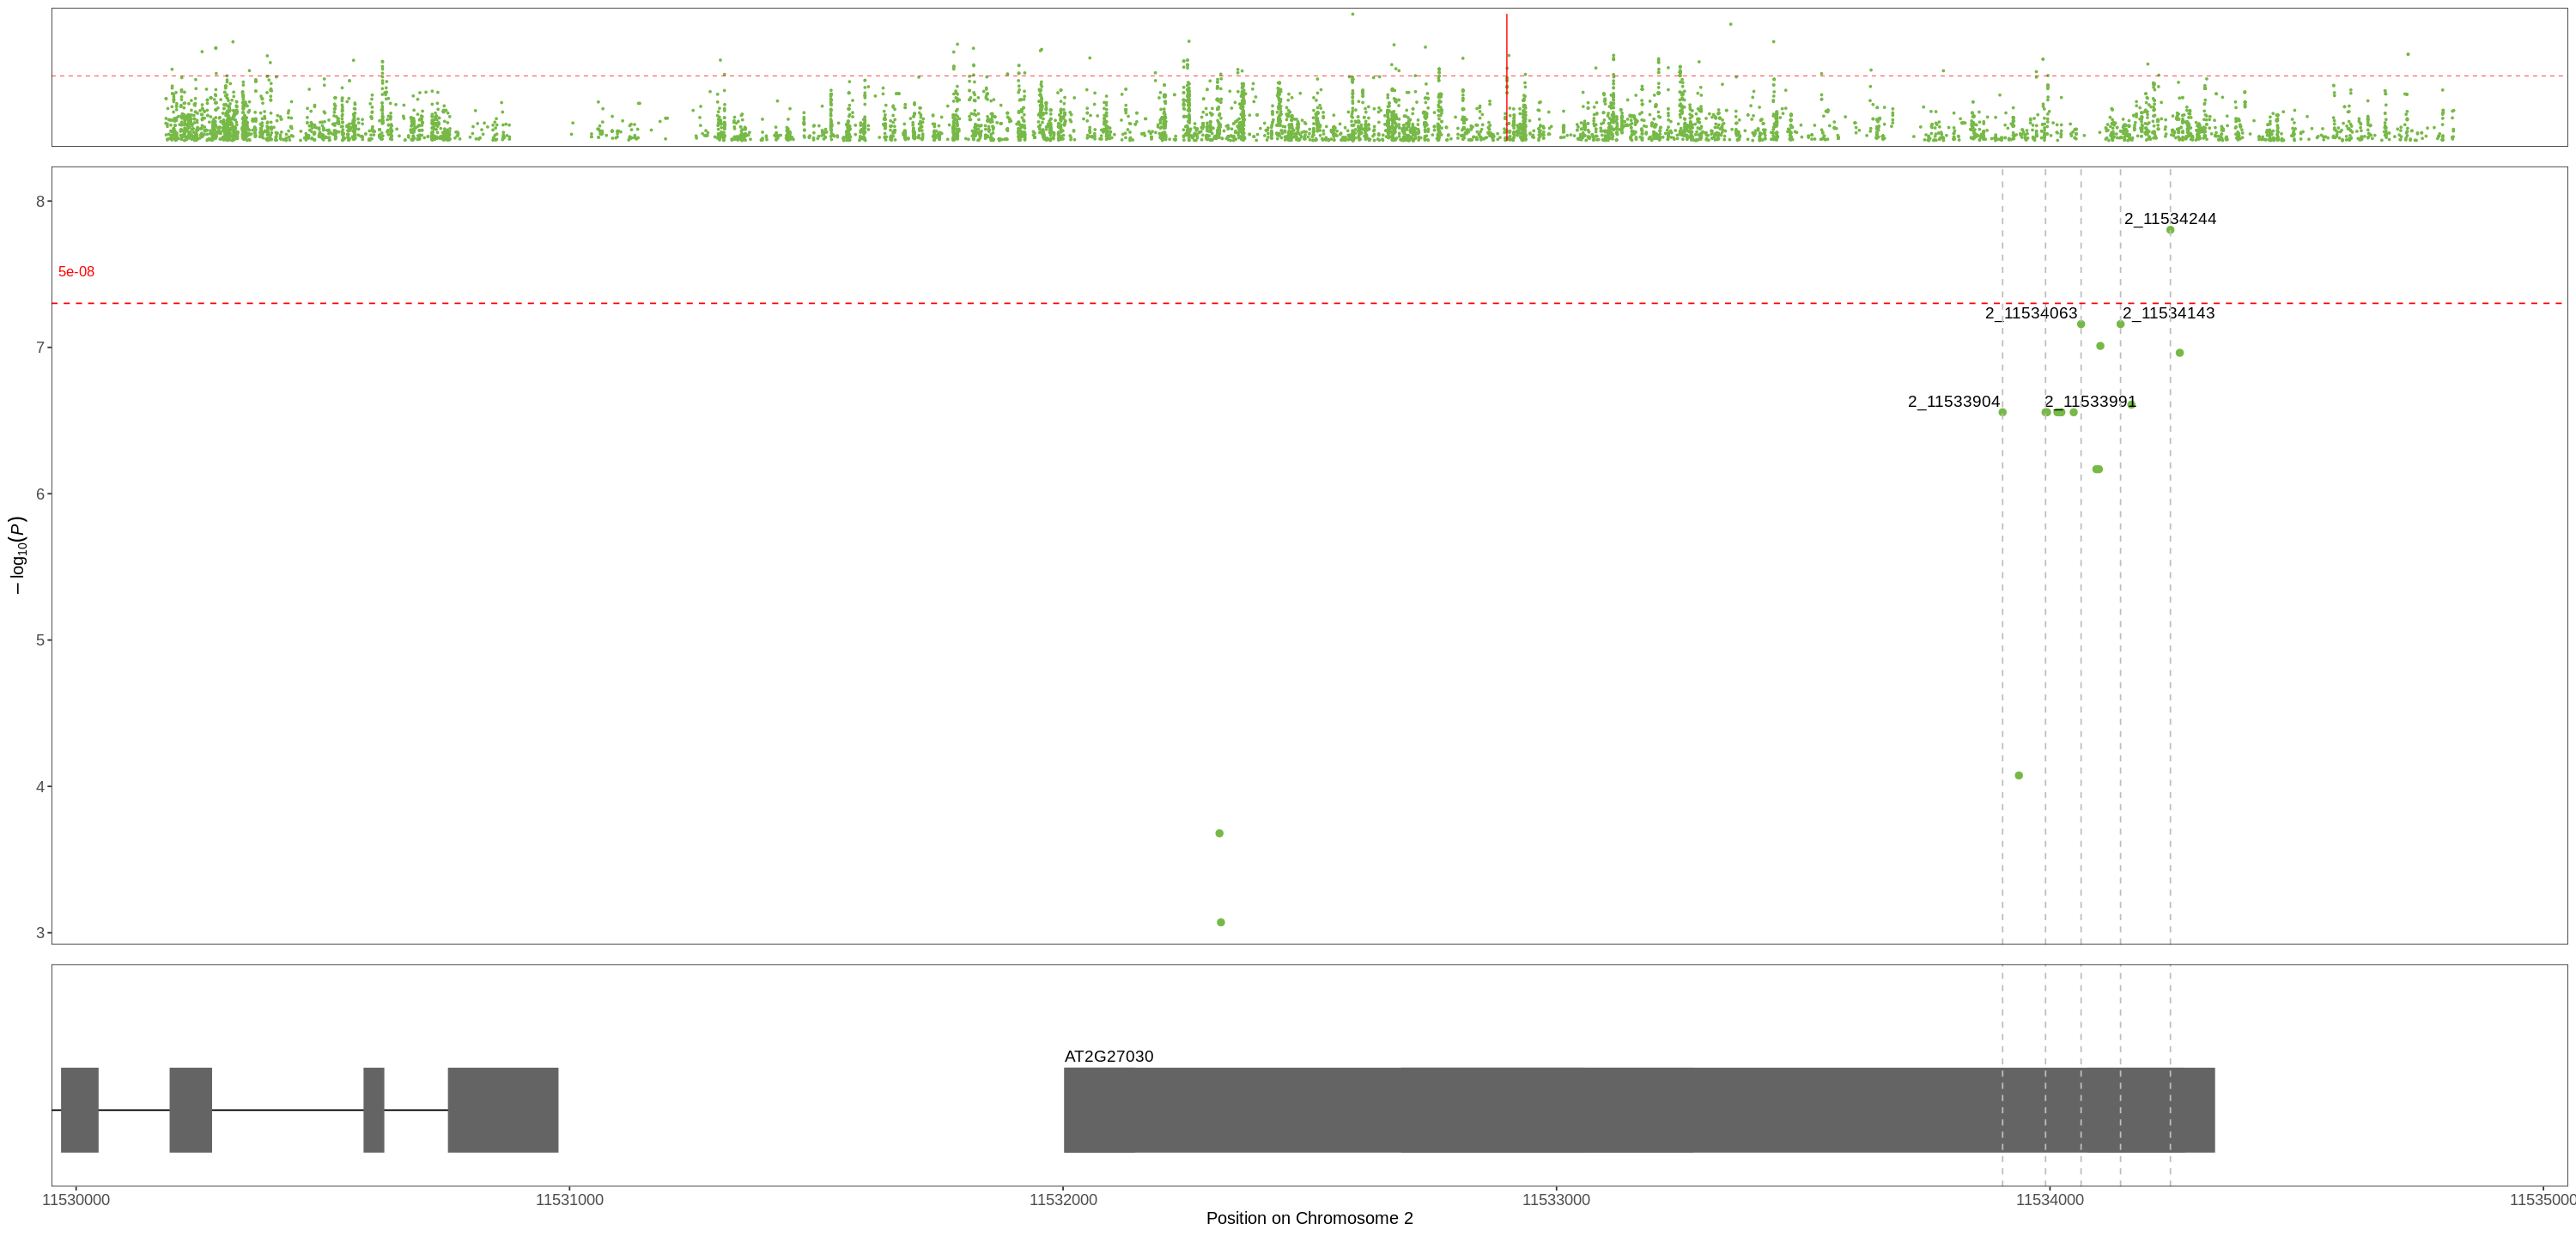

In [23]:
options(repr.plot.width = 25, repr.plot.height = 12)

### exploring hte higest peak of LFMM
regionplot(lfmm, region="2:11530000-11535000", build = annotations, color="#76B947",annotate_with_vline=1e-4,region_size=100, 
           gene_color="#646464")

In [ ]:
options(repr.plot.width = 20, repr.plot.height = 14)

### exploring hte higest peak of LFMM
regionplot(lfmm, region="2:11530000-11534263", build = annotations, color="#76B947",annotate_with_vline=1e-4,region_size=100, 
           gene_color="#646464")

In [ ]:
1_26595993' 1_26600195

[1] "There are no SNPs with p-values below 1e-04 in the input dataset. Use the [thresh] argument to lower the threshold."
[1] "Zoomed to region:  1:26595993-26600195"


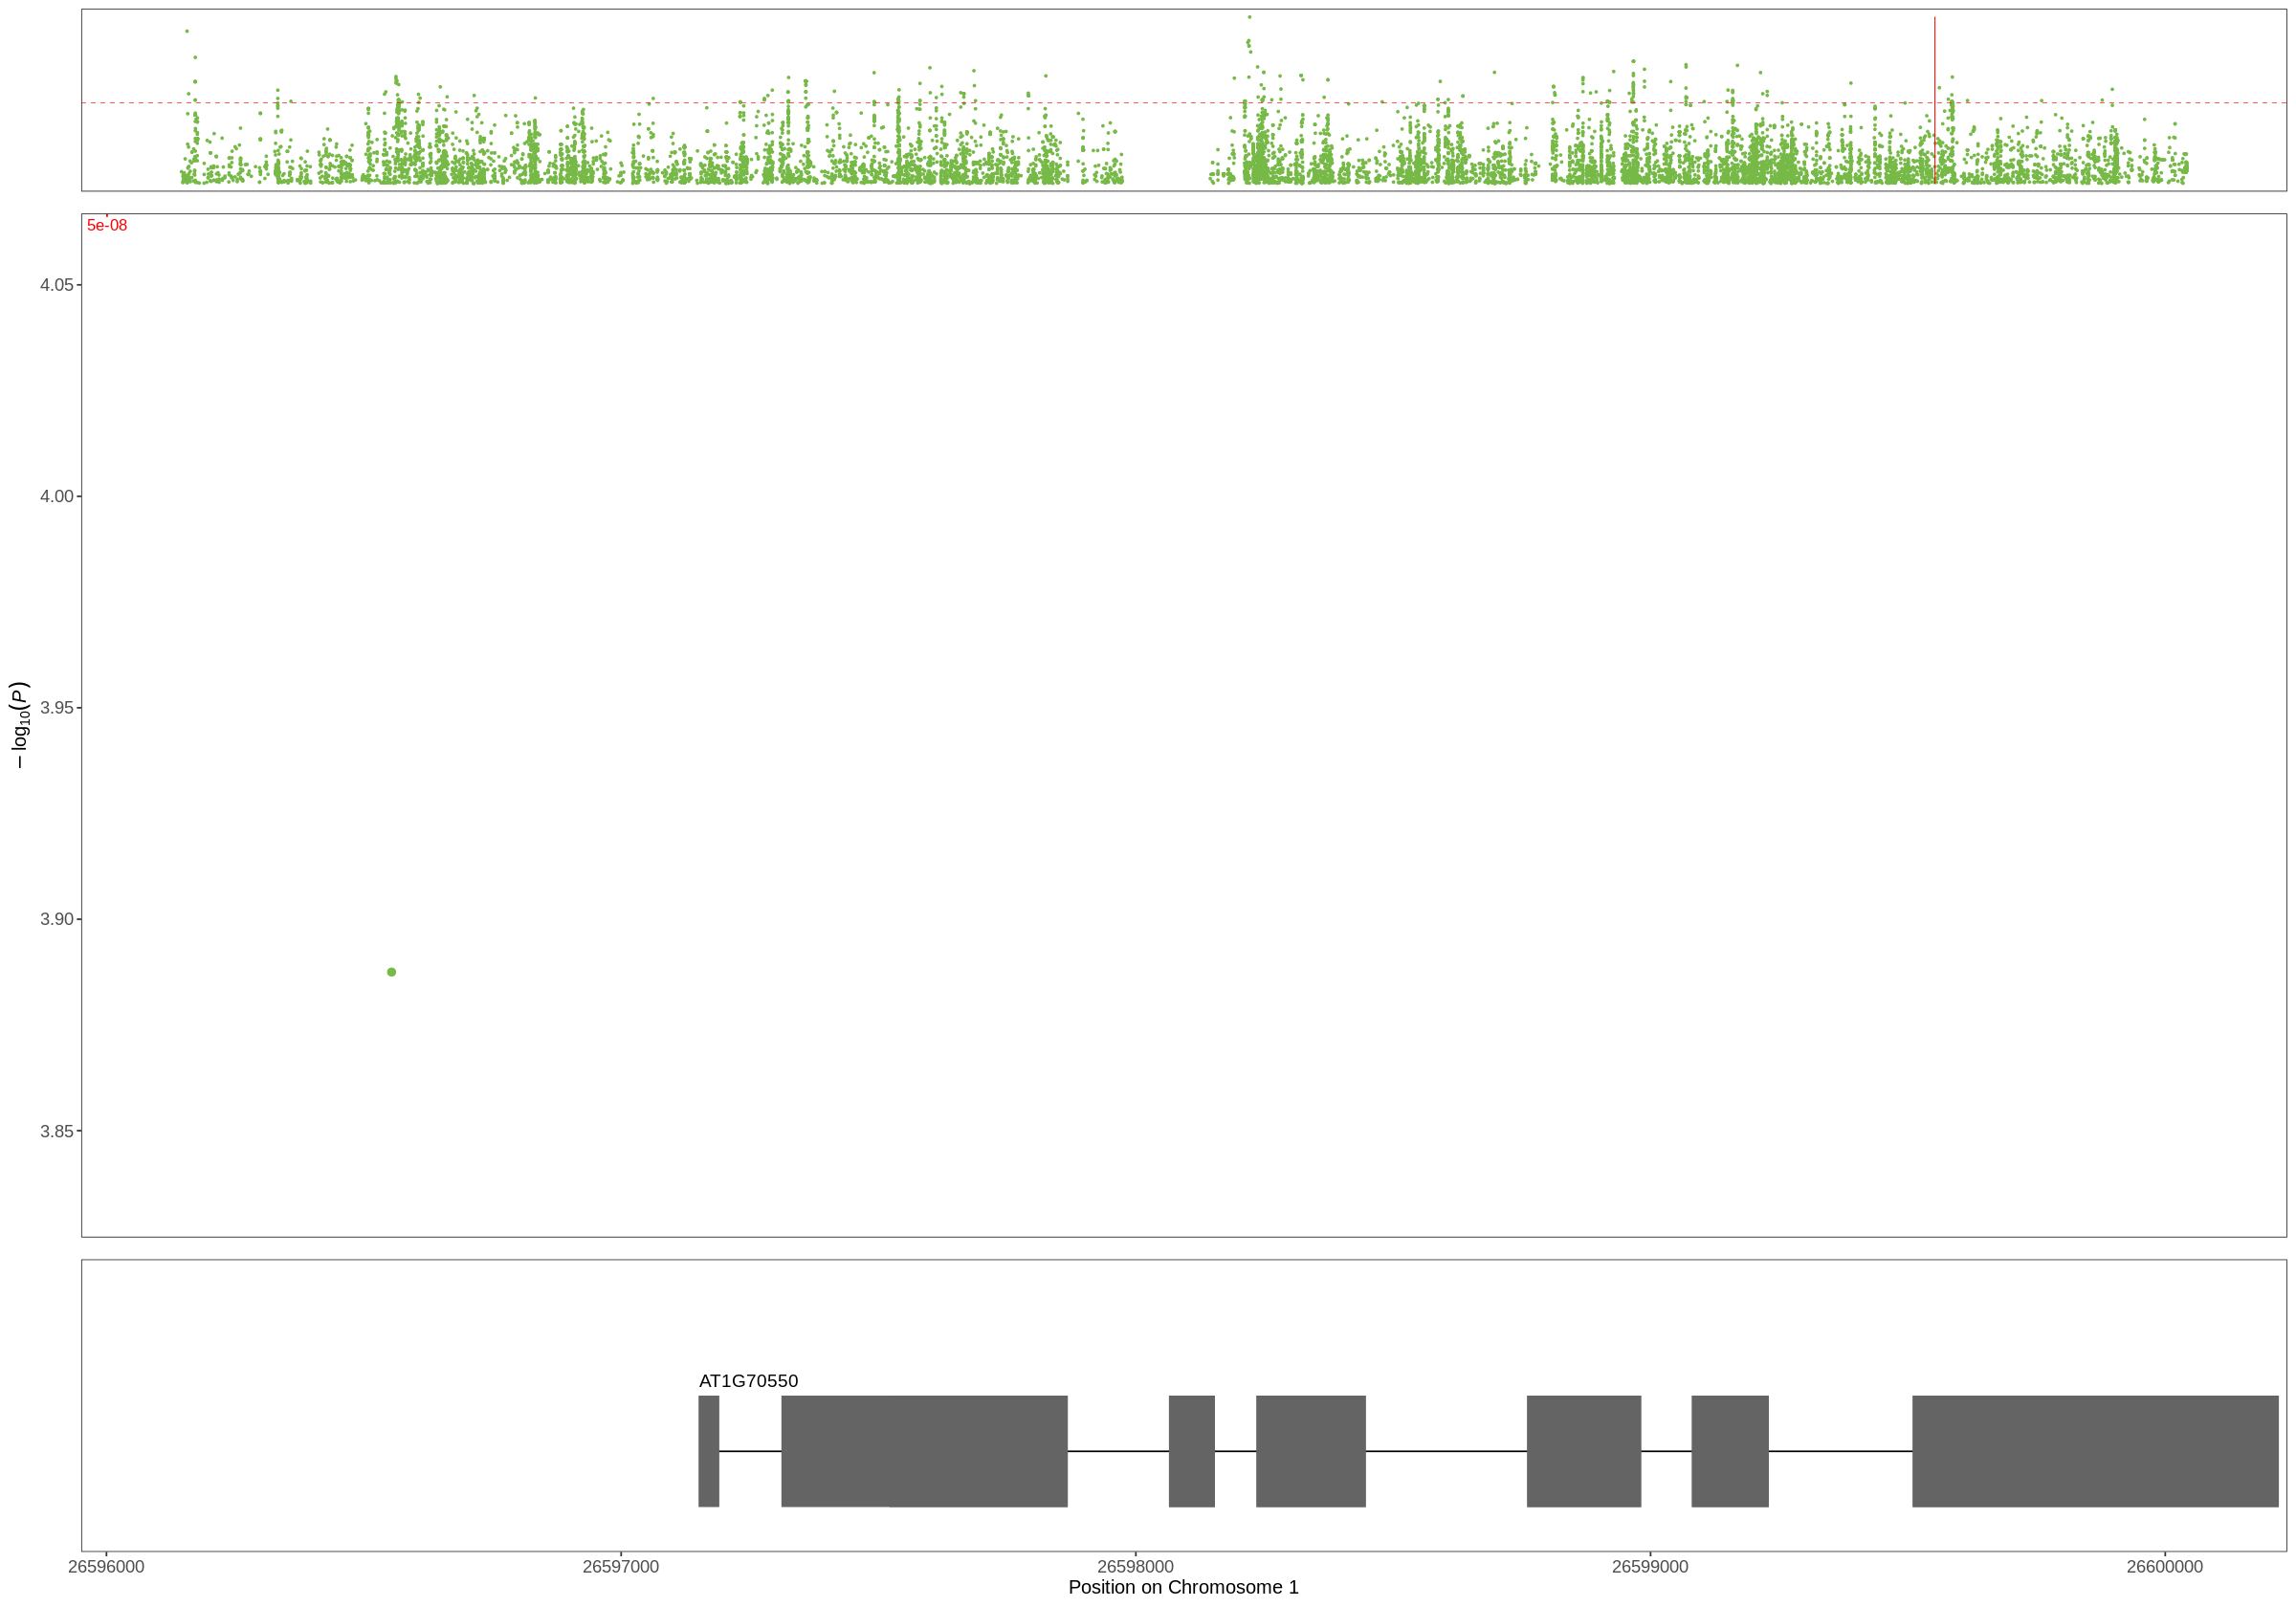

In [26]:
options(repr.plot.width = 20, repr.plot.height = 14)

### exploring hte higest peak of LFMM
regionplot(lfmm, region="1:26595993-26600195", build = annotations, color="#76B947",annotate_with_vline=1e-4,region_size=100, 
           gene_color="#646464")


[1] "There are no SNPs with p-values below 1e-06 in the input dataset. Use the [thresh] argument to lower the threshold."
[1] "Zoomed to region:  4:7255726-7269426"


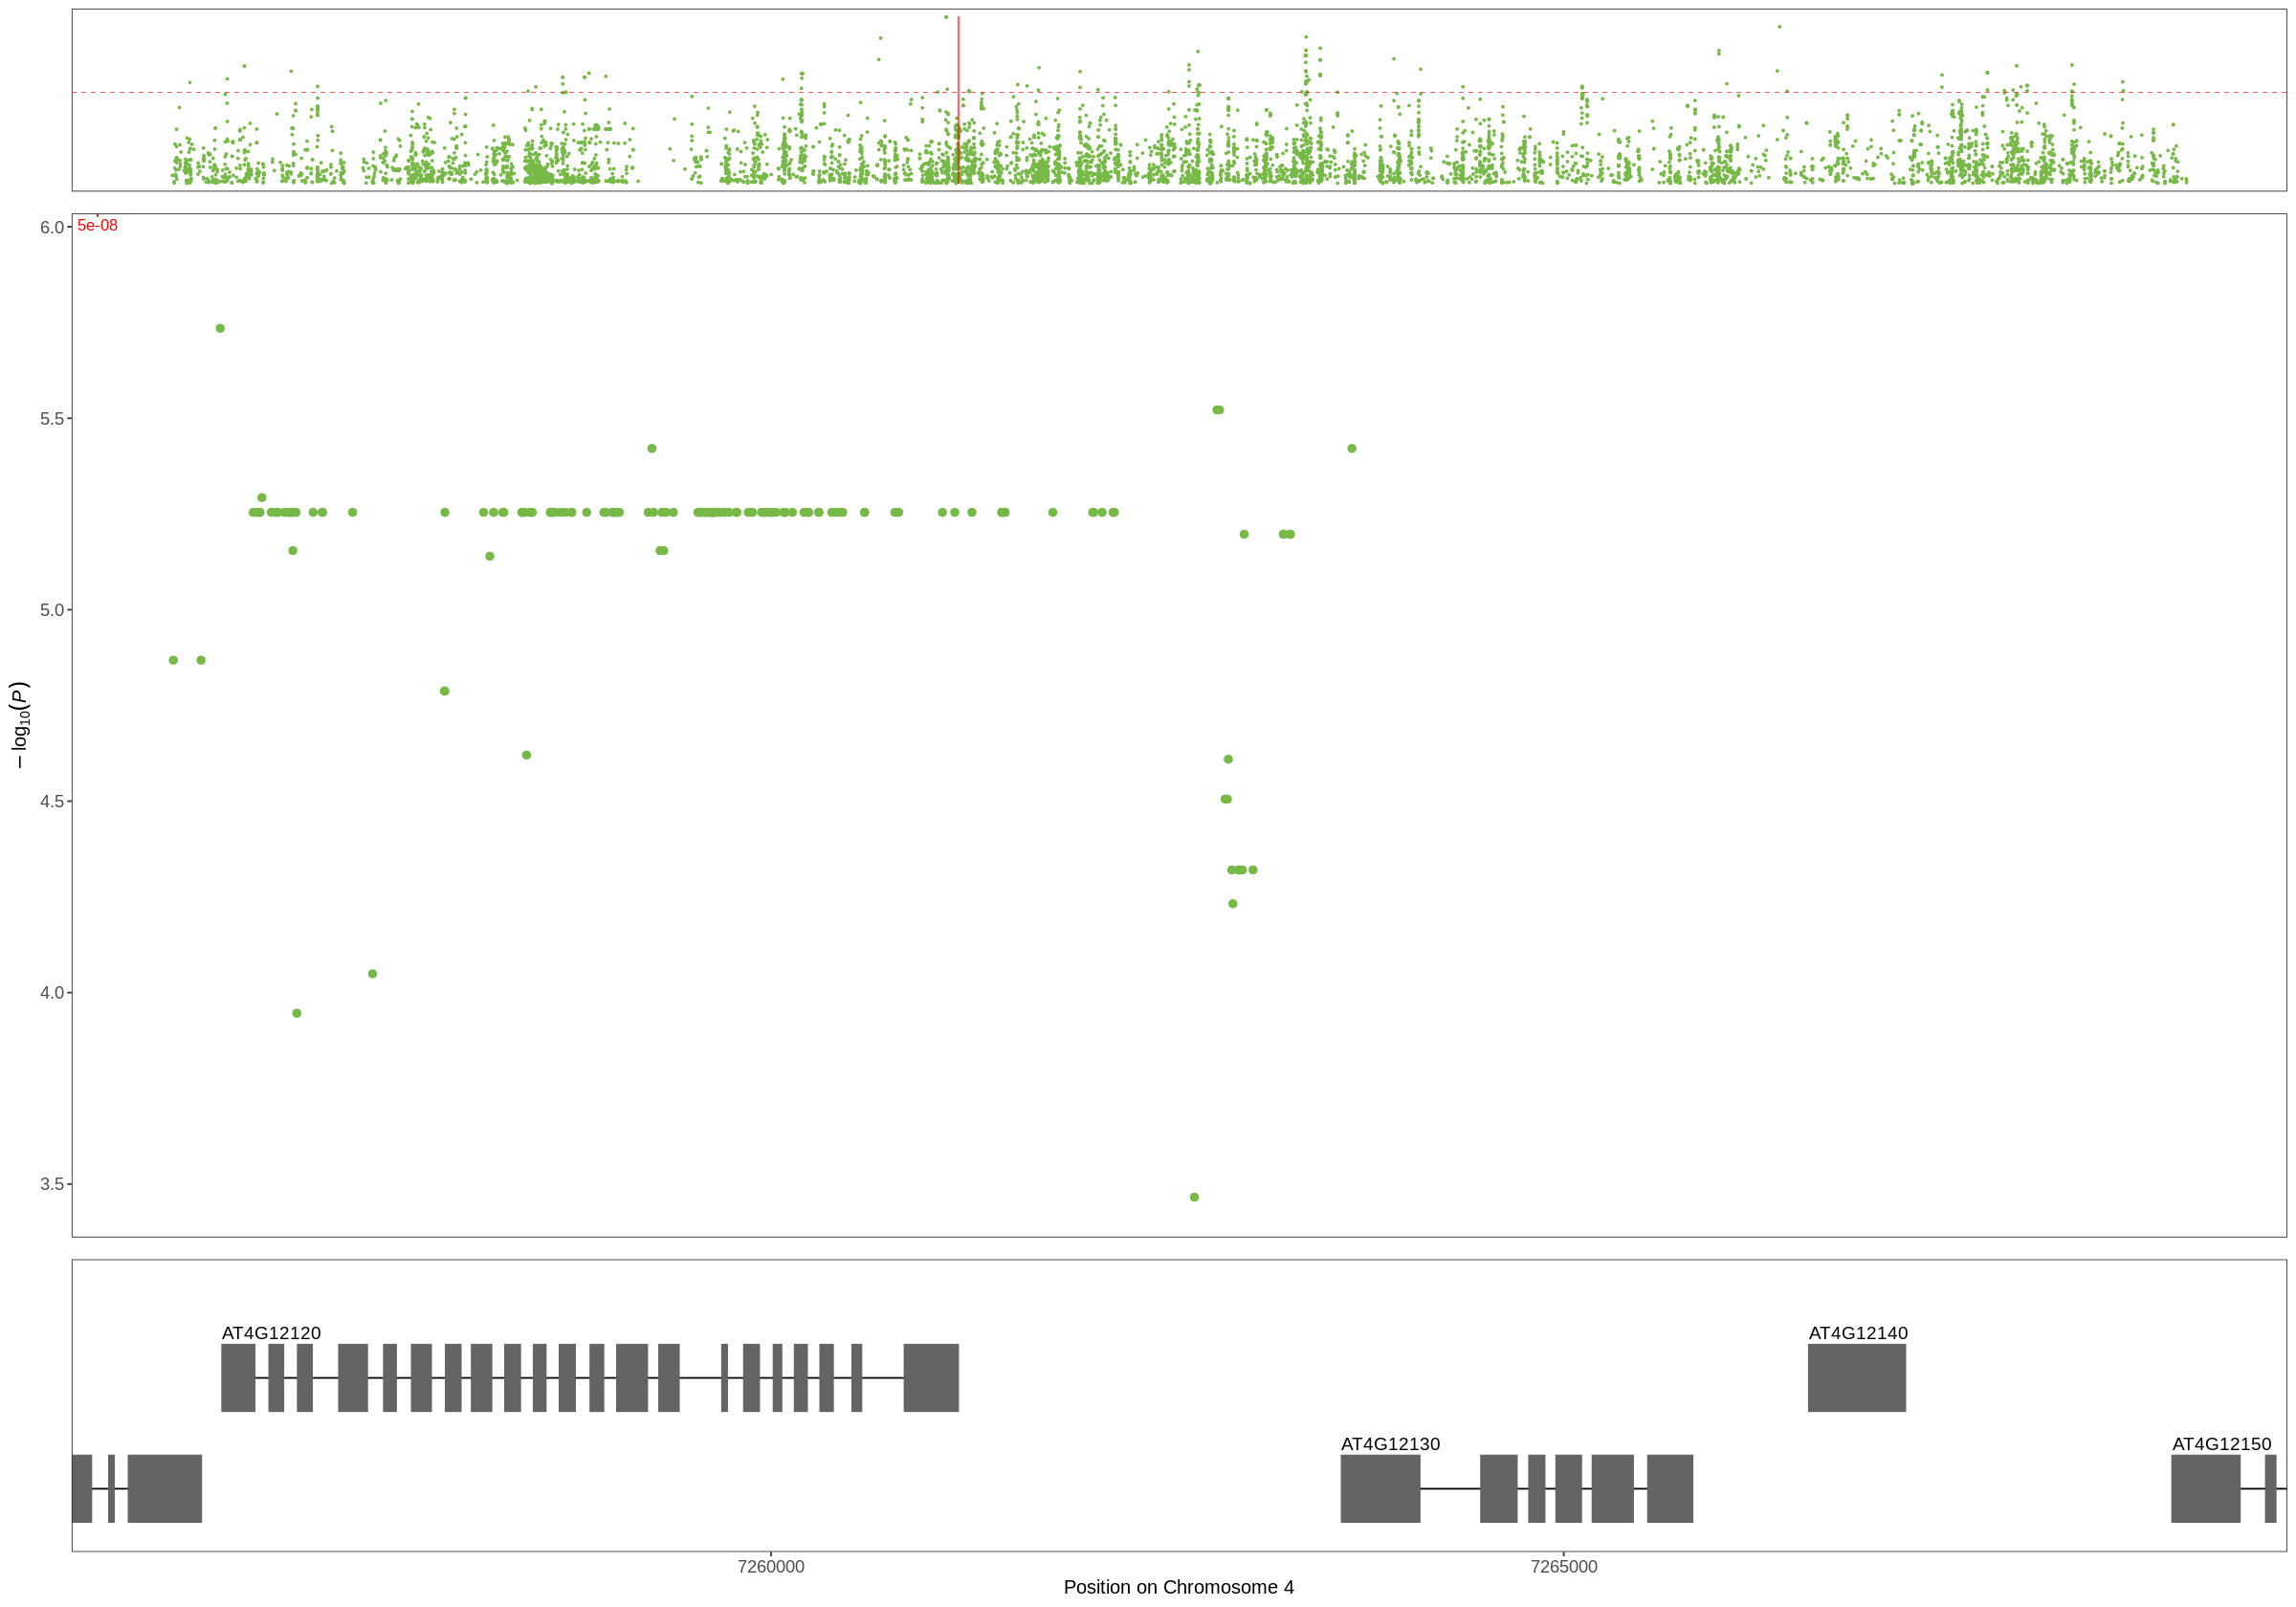

In [28]:
options(repr.plot.width = 20, repr.plot.height = 14)

### exploring hte higest peak of LFMM
regionplot(lfmm, region="4:7255726-7269426", build = annotations, color="#76B947",annotate_with_vline=1e-6,region_size=100, 
           gene_color="#646464")

In [ ]:
# '4_7255726' '4_7269426'

In [33]:
lfmm_sorted <- lfmm[order(lfmm$P), ]


In [34]:
lfmm_sorted

,P,CHROM,POS
,<dbl>,<int>,<int>
55919,4.693291e-14,5,18606097
56816,9.056114e-14,5,19686088
56815,1.577997e-13,5,19685939
56811,1.937887e-13,5,19685790
56812,1.937887e-13,5,19685800
7225,1.266106e-12,1,16212635
56814,3.340334e-12,5,19685847
21568,3.993340e-12,2,10218346
32051,4.673626e-12,3,11405254


[1] "Zoomed to region:  2:9540996-9714921"


Warning message:
“ggrepel: 16 unlabeled data points (too many overlaps). Consider increasing max.overlaps”


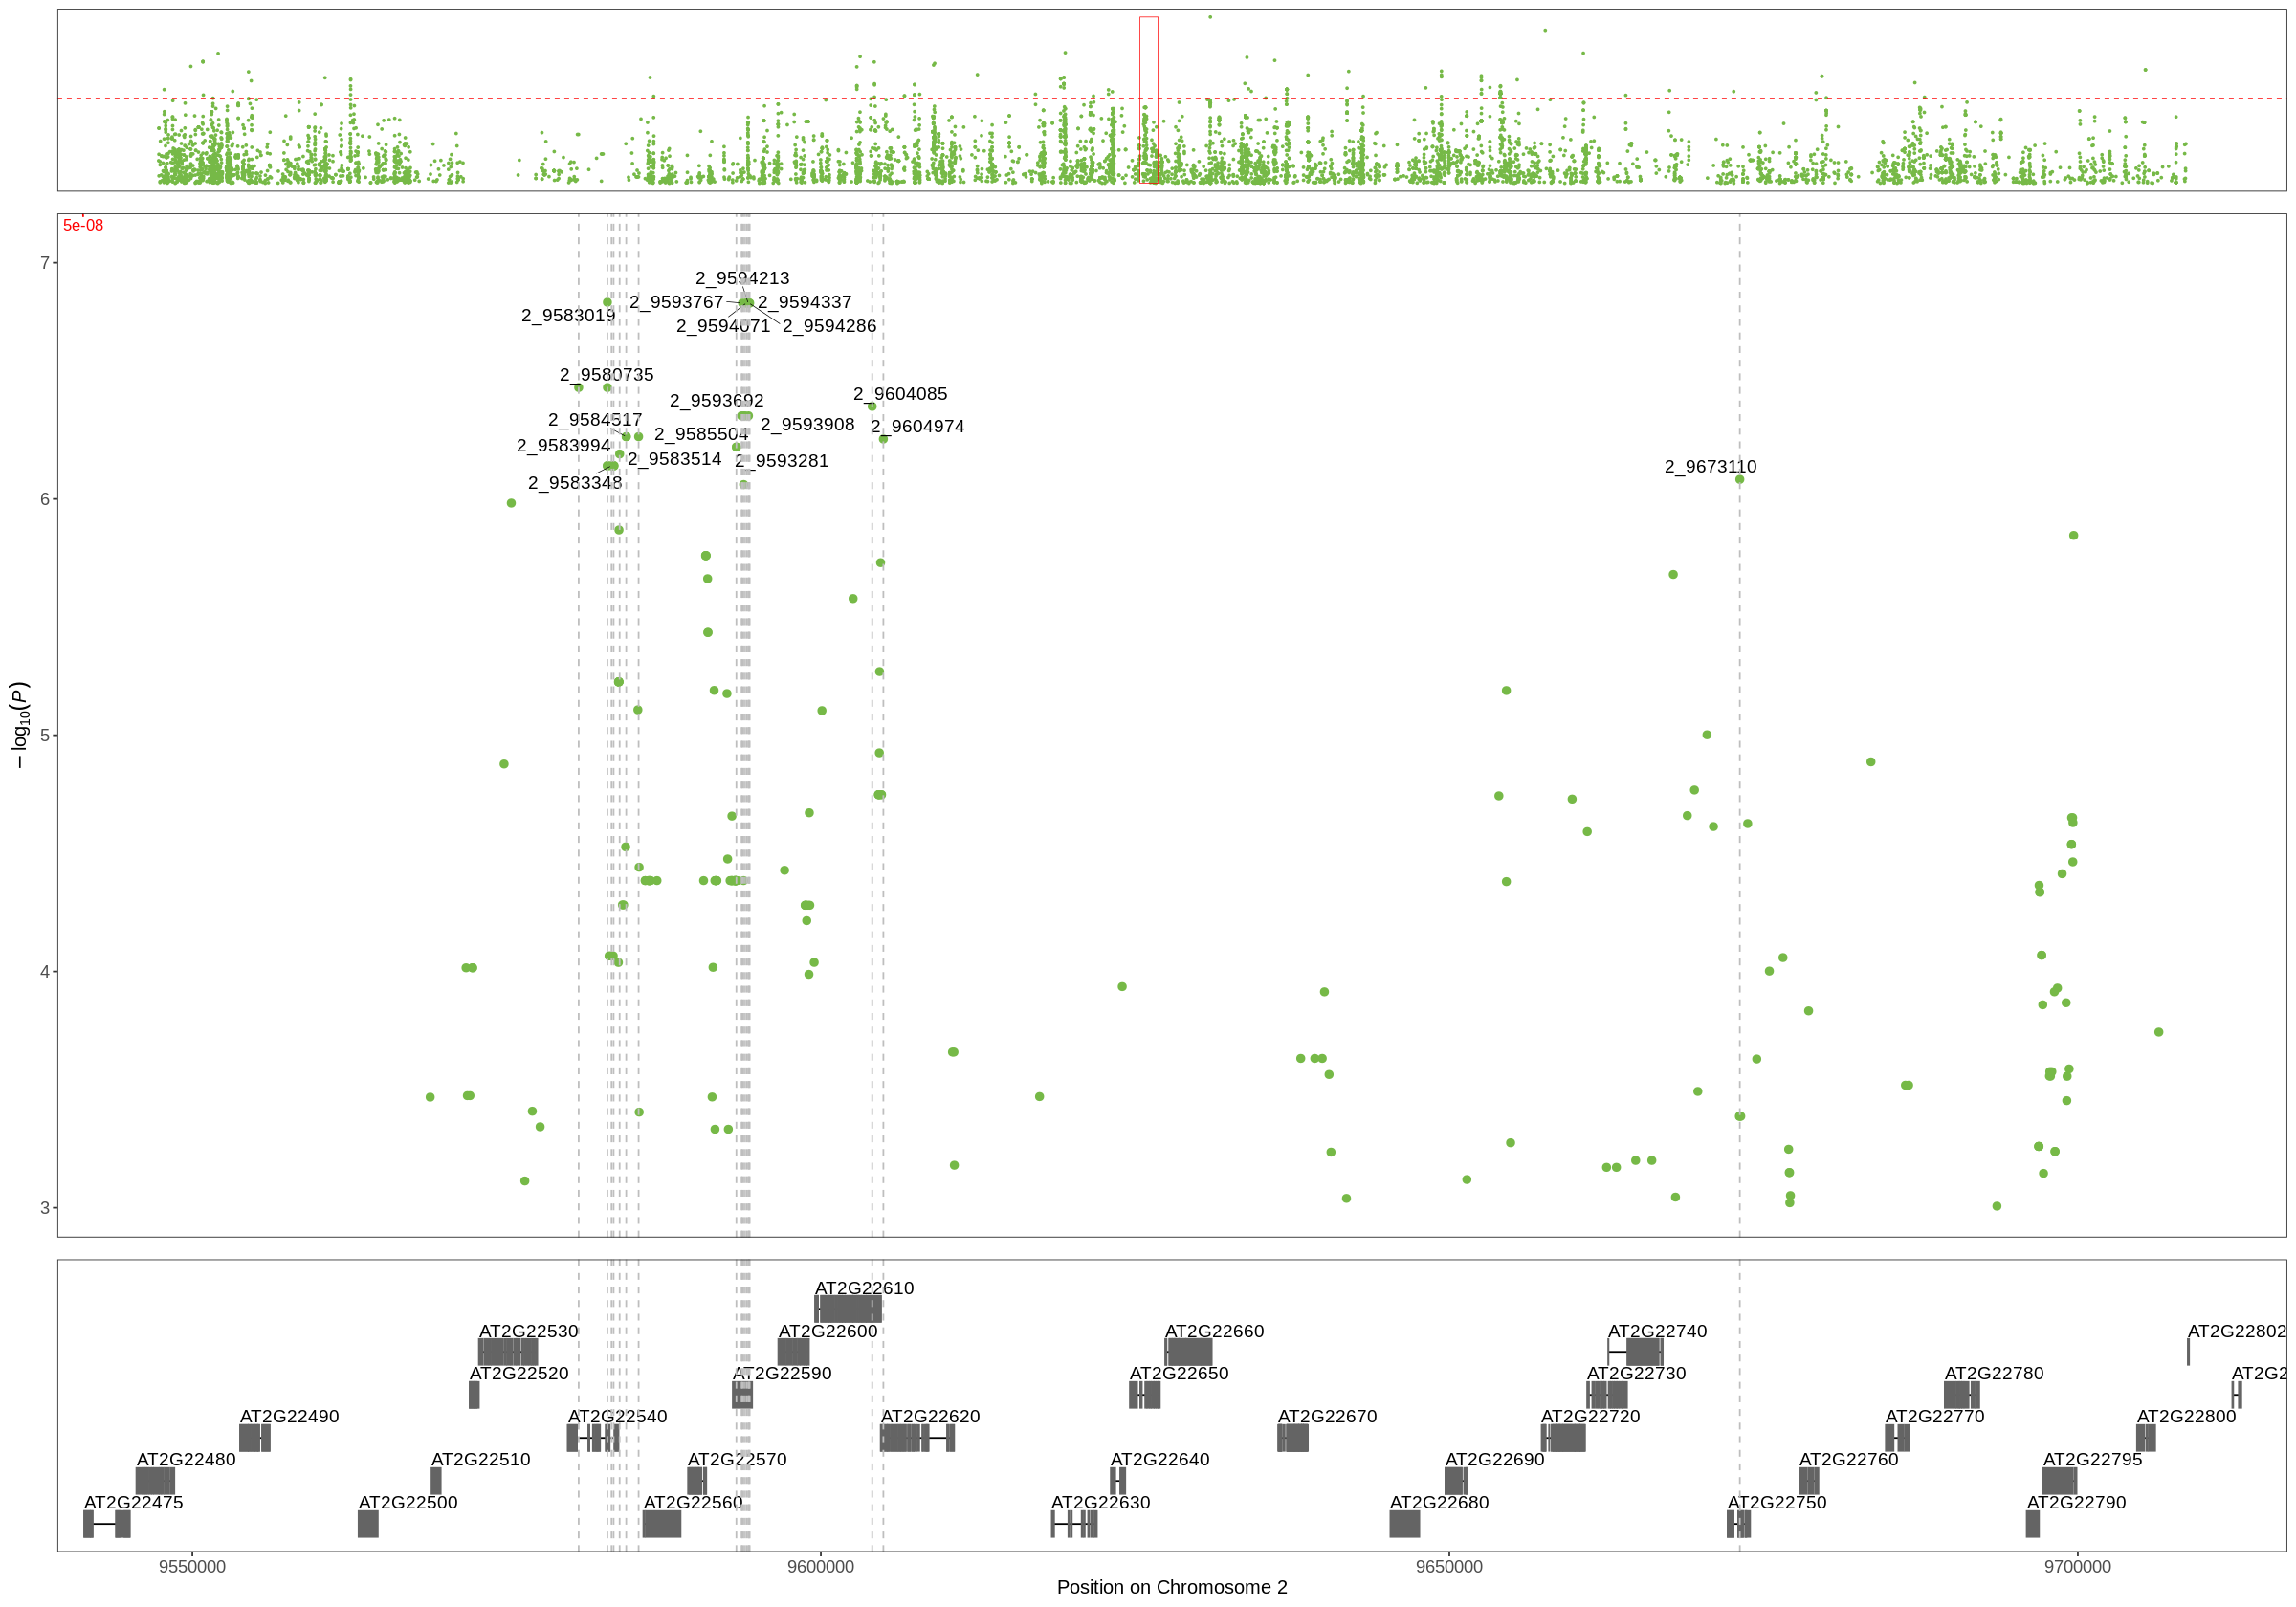

In [31]:
options(repr.plot.width = 20, repr.plot.height = 14)

### exploring hte higest peak of LFMM
regionplot(lfmm, region="2:9540996-9714921", build = annotations, color="#76B947",annotate_with_vline=1e-6,region_size=100, 
           gene_color="#646464")

In [ ]:
2_9540996 2_9714921

In [ ]:
18605097 18607097

[1] "Zoomed to region:  5:18605097-18607097"


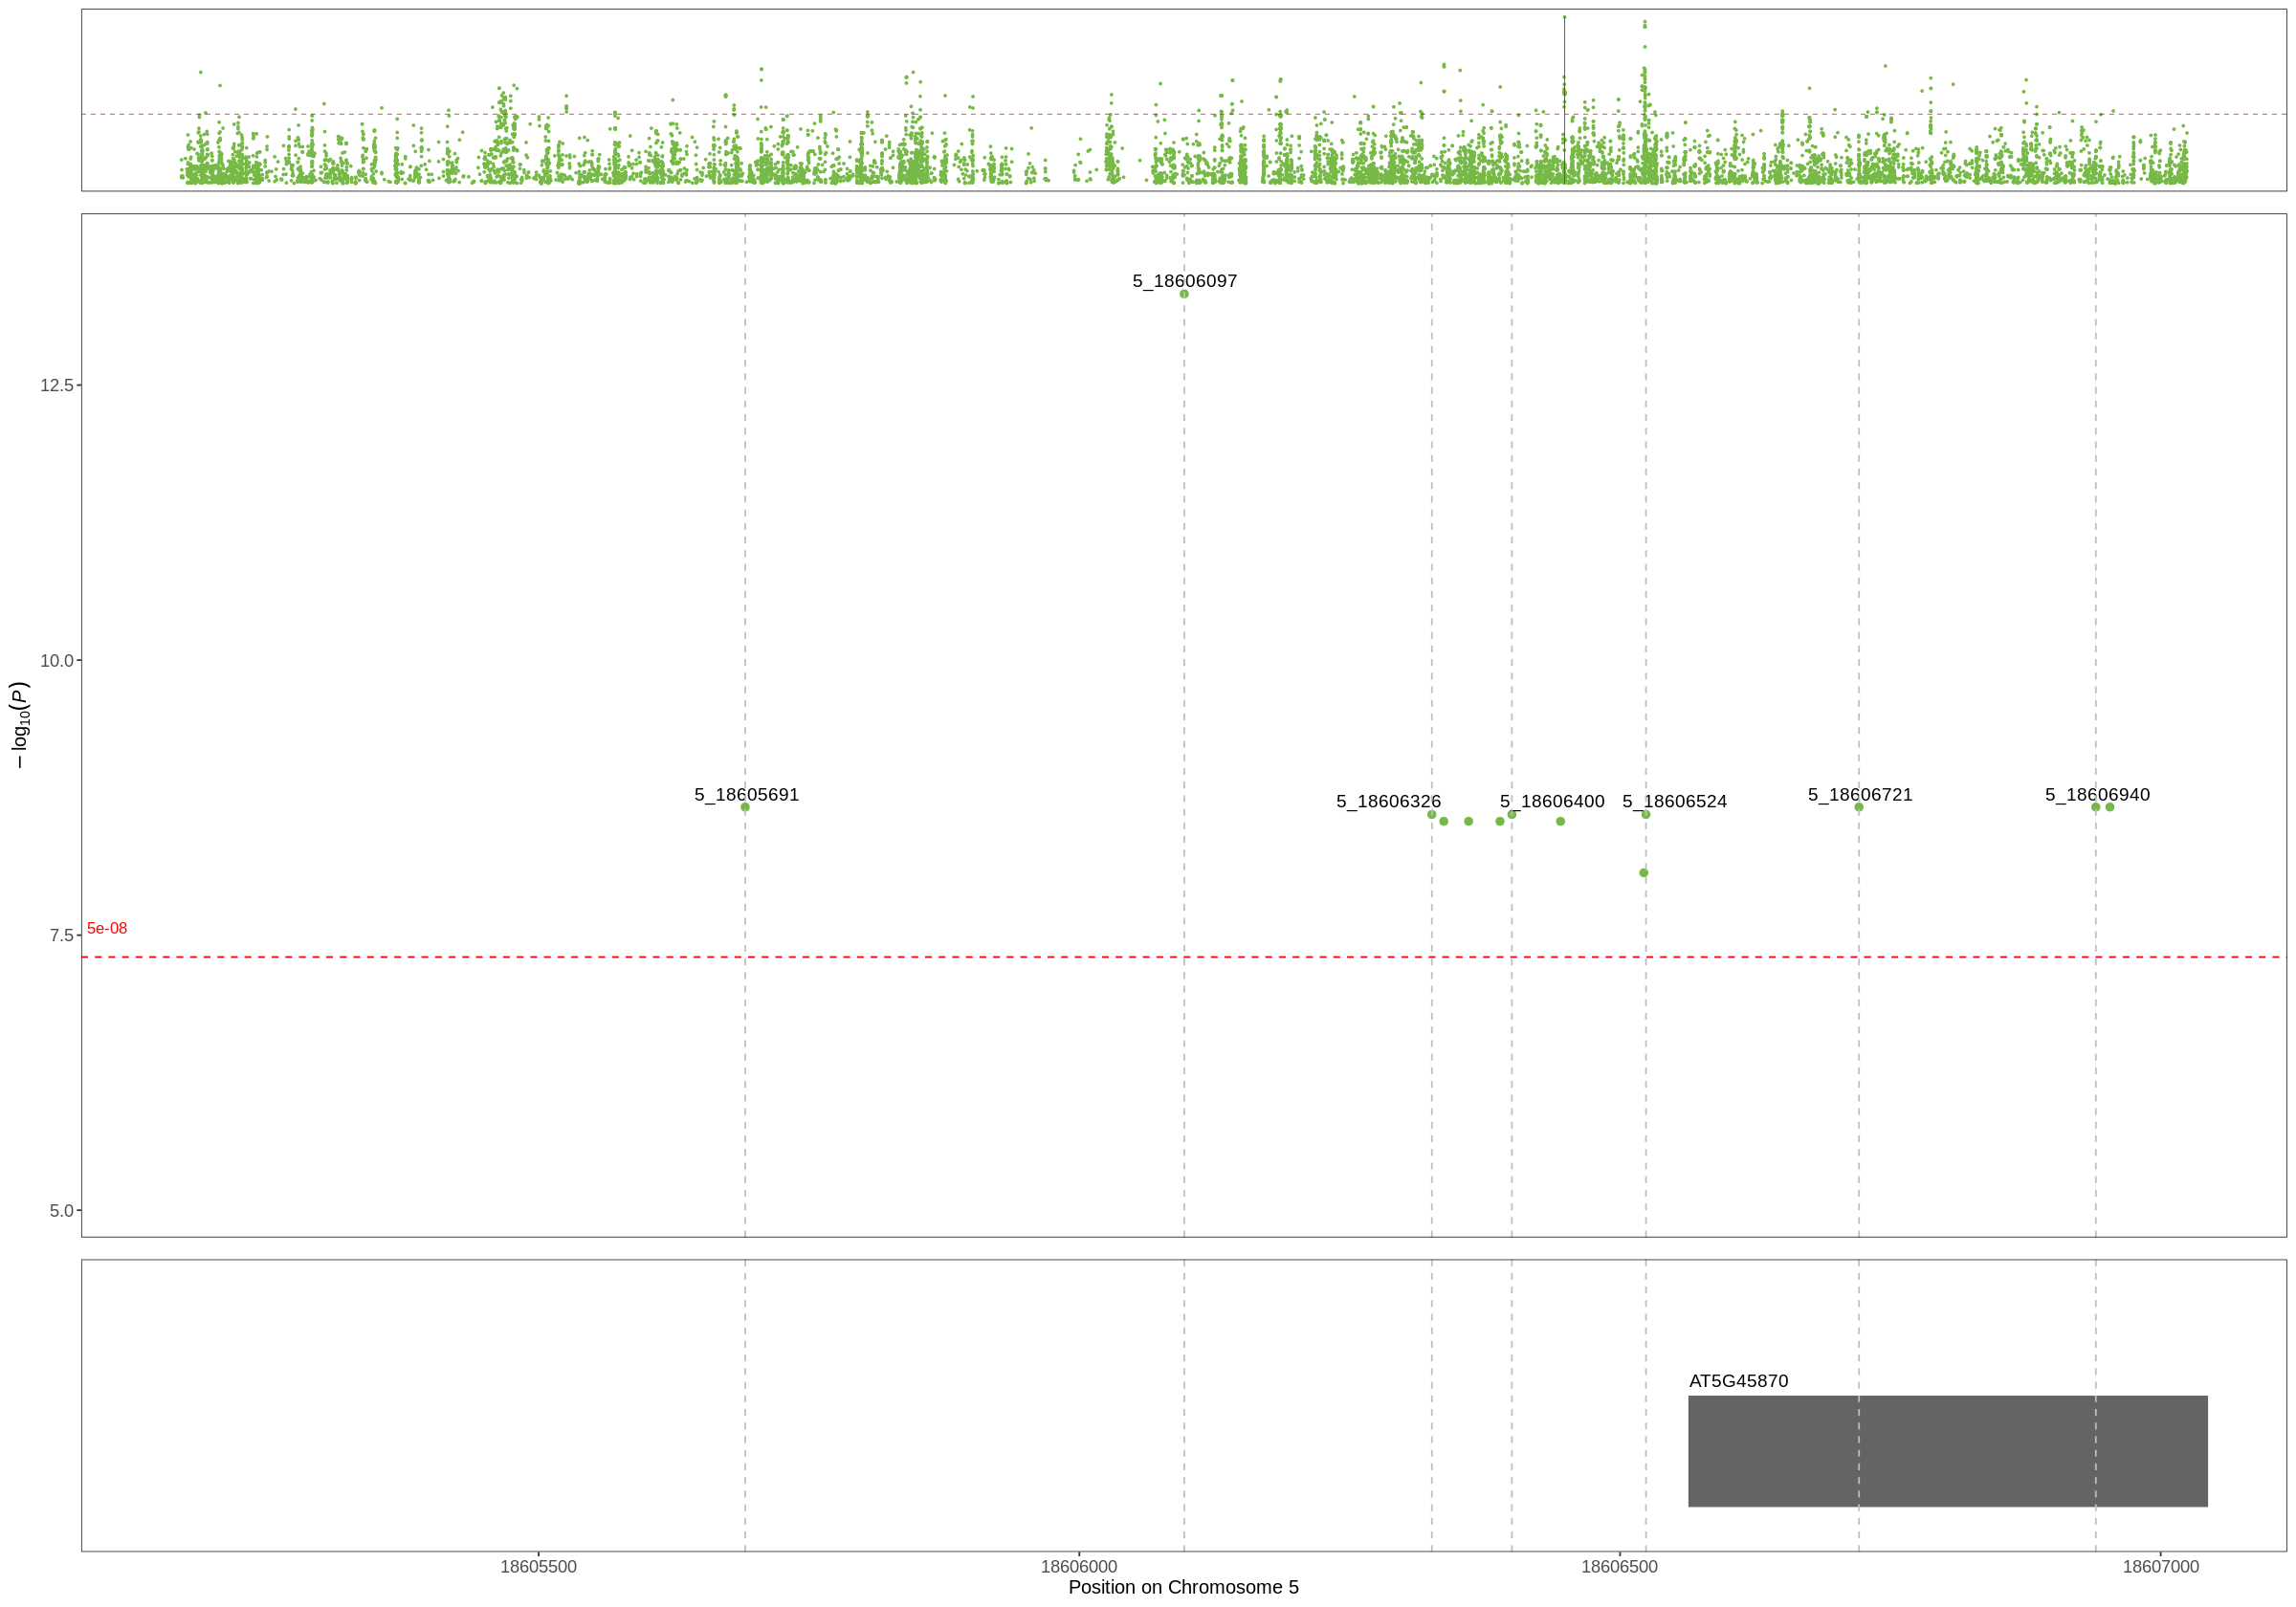

In [35]:
options(repr.plot.width = 20, repr.plot.height = 14)

### exploring hte higest peak of LFMM
regionplot(lfmm, region="5:18605097-18607097", build = annotations, color="#76B947",annotate_with_vline=1e-6,region_size=100, 
           gene_color="#646464")

[1] "Zoomed to region:  5:19684006-19687151"


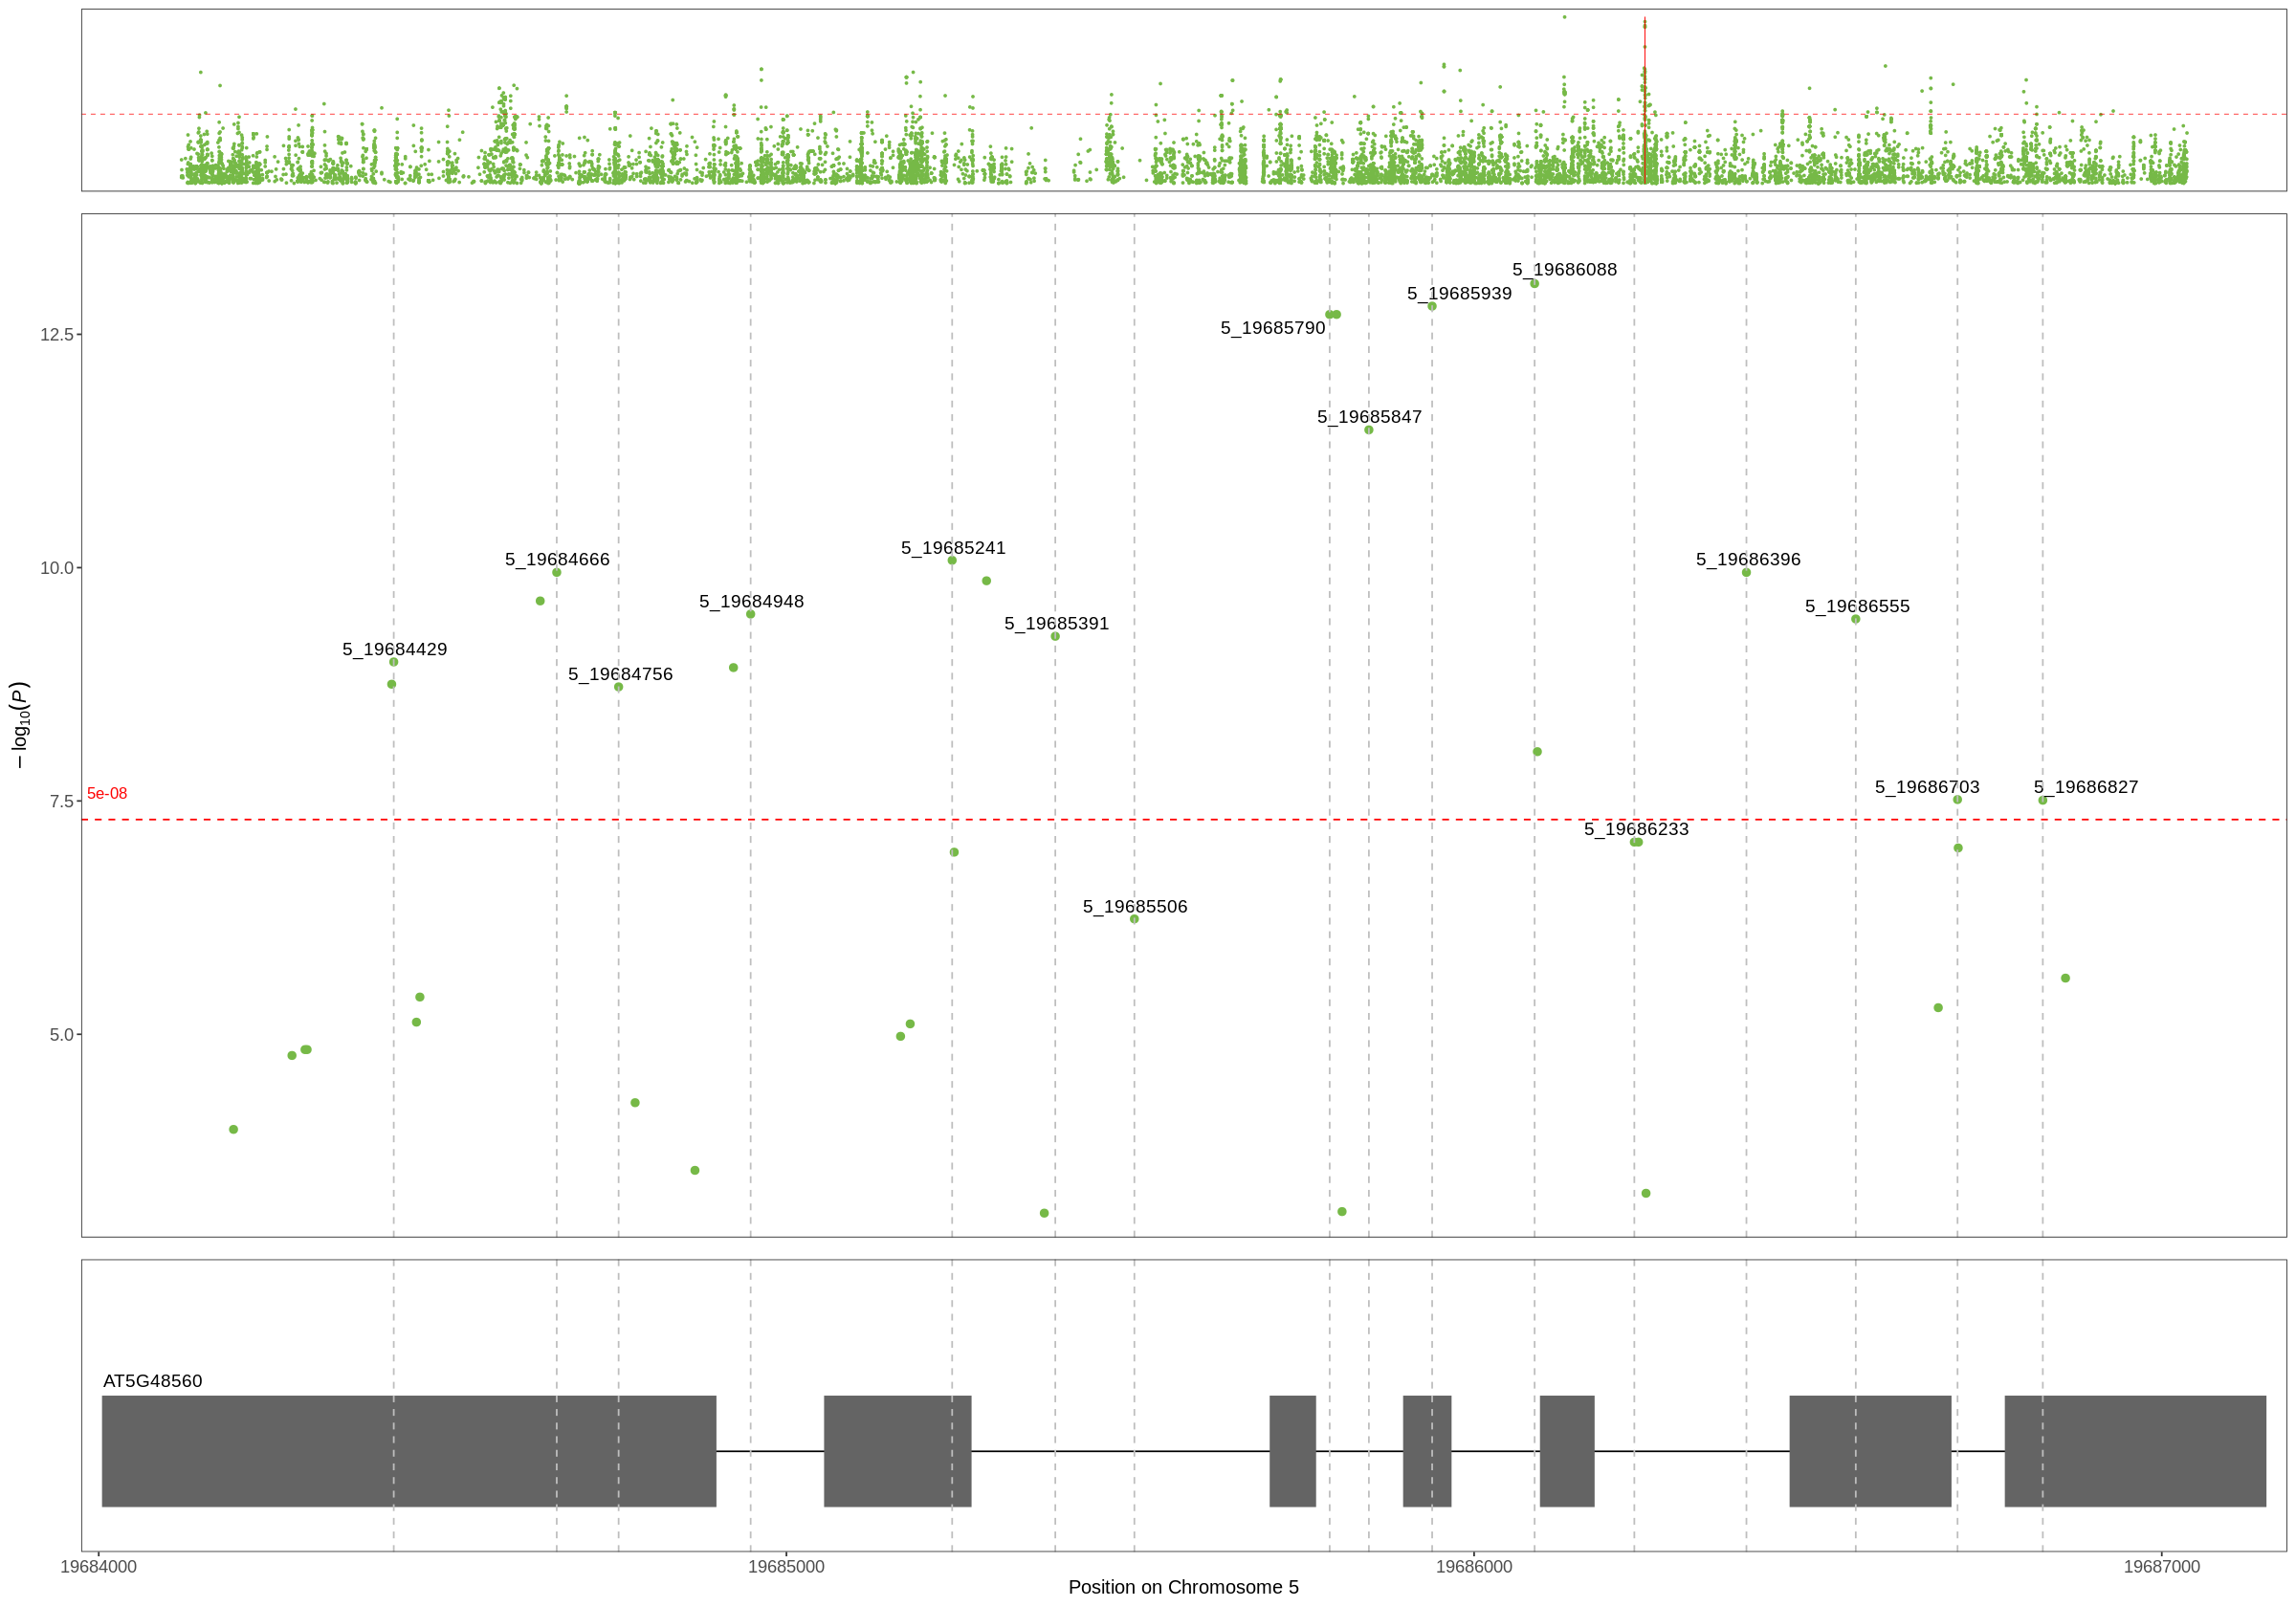

In [41]:
options(repr.plot.width = 20, repr.plot.height = 14)

### exploring hte higest peak of LFMM
regionplot(lfmm, region="5:19684006-19687151", build = annotations, color="#76B947",annotate_with_vline=1e-6,region_size=100, 
           gene_color="#646464")

In [ ]:
19685088 19687088

In [ ]:
19684006	19687151

In [ ]:
AT2G22590

In [ ]:
## plot lfmm and gemma results together
## start and end of the intersting block 2_973 2_9718274 2_9888341
## make it smaller 9750000
# climate_gwas_lfmm_block_2_973.pdf
regionplot(list(gemma, lfmm), region="2:9750000-9888341", build = annotations,
           annotate_with_vline = 1e-8, color=c("#808080","#76B947"),
           legend_labels = c("Climate Gwas", "GEA"), show_gene_legend = F,
           gene_color="#646464")